# FINAL: additional plots

Set **`DATASET`** in cell 2 (`mnist` or `cifar10`). Requires cached runs under `results_analysis/{mnist|cifar}/`. Plots go to `local/save/plots/FINAL/{mnist|cifar}/additional/`.

CIFAR emits paired `_inception` / `_resnet` PDFs. Never pool MNIST+CIFAR. Neuro ground-truth overlays apply to both datasets.


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
DATASET = "mnist"  # or "cifar10"


In [3]:
import sys
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt

def _find_project_root(start: Path | None = None) -> Path:
	p = (start or Path.cwd()).resolve()
	for cand in [p, *p.parents]:
		if (cand / "pyproject.toml").is_file():
			return cand
	return p

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))

from analysis.common import _opt_display, _sort_optimizer_ids
from analysis.dataset_filter import prepare_results_tree
from analysis.io import scan_results
from analysis.final.final_analysis_config import (
	FIND_PEAKS_KWARGS_BY_DATASET,
	FIND_PEAKS_KWARGS_CONTROLGLOBAL_SHUFFLE_ALL_BY_DATASET,
	PEAK_MARKER_LINEWIDTH,
	PEAK_MARKER_SIZE,
	TRAIN_LOSS_LINE_ALPHA,
	dataset_key,
	model_ids_for_dataset,
	plot_dir_for_dataset,
	save_dir_for_dataset,
)
from analysis.final.final_experiment_display import (
	ExperimentDisplayLabels,
	normalize_experiment_display_label,
	rename_experiments_for_labels,
	sort_experiment_display_names,
)
from analysis.final.final_additional_plots_helpers import (
	apply_presentation_defaults,
	aggregate_layer_metric_mean_sem,
	build_btsp_neuron_pct_rows,
	build_layer_mean_score_rows,
	build_layer_period_score_rows,
	print_mean_score_across_layers,
	build_btsp_neuron_pct_segment_rows,
	build_peak_ratio_df,
	build_period_metrics_df,
	cat2_shuffle_recover_reinforce_labels,
	facet_bar_by_experiment_cat12,
	facet_bar_by_experiment_row,
	facet_box_welch_cat12,
	load_all_results_from_cache,
	overlay_layer_group_mean_regression,
	overlay_layer_per_optimizer_regression,
	pool_btsp_mean_over_experiments,
	plot_btsp_neuron_pct_segment_trajectories,
	plot_btsp_pooled_optimizer_layer_bars,
	build_latex_table,
	plot_correlation_matrices_pooled_by_experiment,
	plot_correlation_matrix_global_pool,
	plot_correlations_per_experiment,
	plot_correlations_pooled_by_optimizer,
	plot_debug_training_loss_peaks,
	find_peaks_params_label,
	print_peak_ratio_pooled_summaries,
	_sort_layer_display_names,
	_fixed_ylim_for_metric,
)
from analysis.final.plot_dataset_context import (
	filter_all_results,
	filter_tree,
	iter_model_plot_contexts,
	with_arch_filename,
	with_arch_title,
)

MODEL_IDS = model_ids_for_dataset(DATASET)
SAVE_DIR = str(save_dir_for_dataset(PROJECT_ROOT, DATASET))
PLOT_DIR = plot_dir_for_dataset(DATASET, additional=True)
Path(PLOT_DIR).mkdir(parents=True, exist_ok=True)

SIG_BRACKET_STEP_FRAC = 0.086
SIG_BRACKET_YLIM_PAD_FRAC = 0.175
_CAT2_EARLY_ZOOM_N_TRIALS = 4
_CAT2_EARLY_ZOOM_MAX_ITER = 400

_EXPER_LABEL_SHUFFLE_ALL = r"$\text{Shuffle}_{all}$"
_EXPER_LABEL_SHUFFLE_NOPRE = "Control global (✗PT)"
_EXPER_LABEL_SHUFFLE_INTERLEAVED = r"$\text{Shuffle}_{interleaved}$"
_EXPER_LABEL_SEQ_NOPRE = "Control sequential (✗PT)"
_EXPER_LABEL_SEQ_PRE = "Control sequential (✔PT)"
_EXPER_LABEL_SHUFFLE_SEQ = r"$\text{Shuffle}_{seq}$"
_EXPER_LABEL_NO_PRETRAIN = " Control (no pretrain)"

LABELS = ExperimentDisplayLabels(
	shuffle_all=_EXPER_LABEL_SHUFFLE_ALL,
	shuffle_interleaved=_EXPER_LABEL_SHUFFLE_INTERLEAVED,
	shuffle_nopre=_EXPER_LABEL_SHUFFLE_NOPRE,
	seq_nopre=_EXPER_LABEL_SEQ_NOPRE,
	seq_pre=_EXPER_LABEL_SEQ_PRE,
	shuffle_seq=_EXPER_LABEL_SHUFFLE_SEQ,
	no_pretrain=_EXPER_LABEL_NO_PRETRAIN,
)


def rename_experiments(eid: str) -> str:
	return normalize_experiment_display_label(
		rename_experiments_for_labels(eid, LABELS), LABELS
	)


def _sort_experiment_display_names(labels: Iterable[str]) -> list[str]:
	return sort_experiment_display_names(labels, LABELS)

USE_T_START_INV = False
_CORR_MAT_COLS = ["activation_angle", "total_length_iter", "robustness_score", "t_start"+("_inv" if USE_T_START_INV else "")]
_CORR_MAT_LABELS = ["ang", "len", "rob", (r"$-" if USE_T_START_INV else r"$") + r"{t_{start}}$"]
_CORR_PAIRS = [
	("activation_angle", "total_length_iter", "angle", "length"),
	("activation_angle", "robustness_score", "angle", "robustness"),
	("total_length_iter", "robustness_score", "length", "robustness"),
	("activation_angle", "t_start"+("_inv" if USE_T_START_INV else ""), "angle", (r"$-" if USE_T_START_INV else r"$") + r"{t_{start}}$"),
	("total_length_iter", "t_start"+("_inv" if USE_T_START_INV else ""), "length", (r"$-" if USE_T_START_INV else r"$") + r"{t_{start}}$"),
	("robustness_score", "t_start"+("_inv" if USE_T_START_INV else ""), "robustness", (r"$-" if USE_T_START_INV else r"$") + r"{t_{start}}$"),
]

_PLOT_KW = dict(
	plot_dir=PLOT_DIR,
	sig_bracket_step_frac=SIG_BRACKET_STEP_FRAC,
	sig_bracket_ylim_pad_frac=SIG_BRACKET_YLIM_PAD_FRAC,
	sort_experiment_names=_sort_experiment_display_names,
	labels=LABELS,
)

FIND_PEAKS_KWARGS = FIND_PEAKS_KWARGS_BY_DATASET[DATASET]
FIND_PEAKS_KWARGS_CONTROLGLOBAL_SHUFFLE_ALL = (
	FIND_PEAKS_KWARGS_CONTROLGLOBAL_SHUFFLE_ALL_BY_DATASET[DATASET]
)

apply_presentation_defaults(PLOT_DIR)
tree = scan_results()
tree, skipped = prepare_results_tree(tree, dataset_key(DATASET))
if skipped:
	print("Skipped incomplete result pairs:", skipped)
all_results = load_all_results_from_cache(tree, SAVE_DIR)

if not all_results:
	raise RuntimeError(
		f"No cached runs in {SAVE_DIR}. Run FINAL_compare load cell or analyse_sim_results.py first."
	)
print(f"Loaded {len(all_results)} runs from cache; plots -> {PLOT_DIR}")


Loaded 45 runs from cache; plots -> local/save/plots/FINAL/mnist/additional/


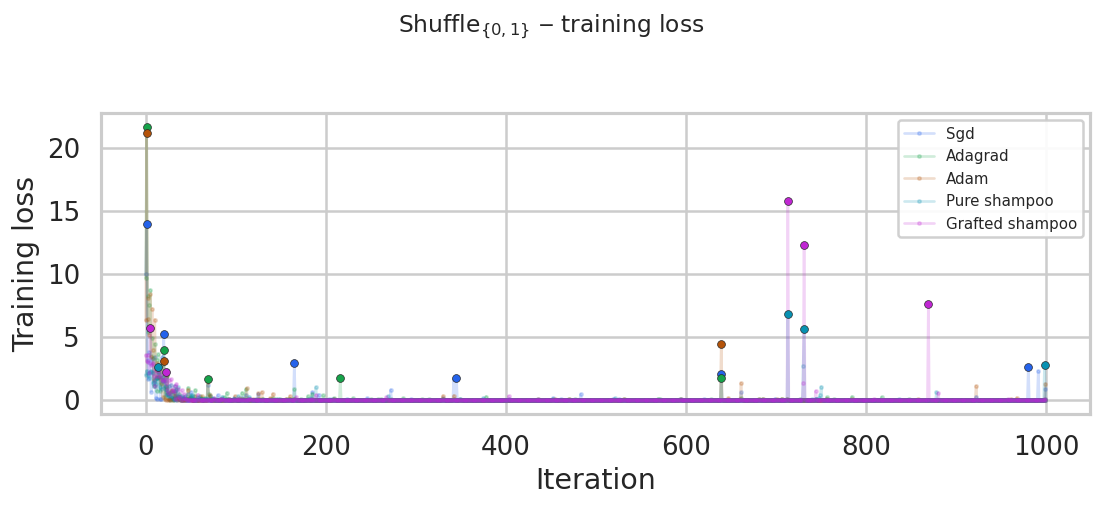

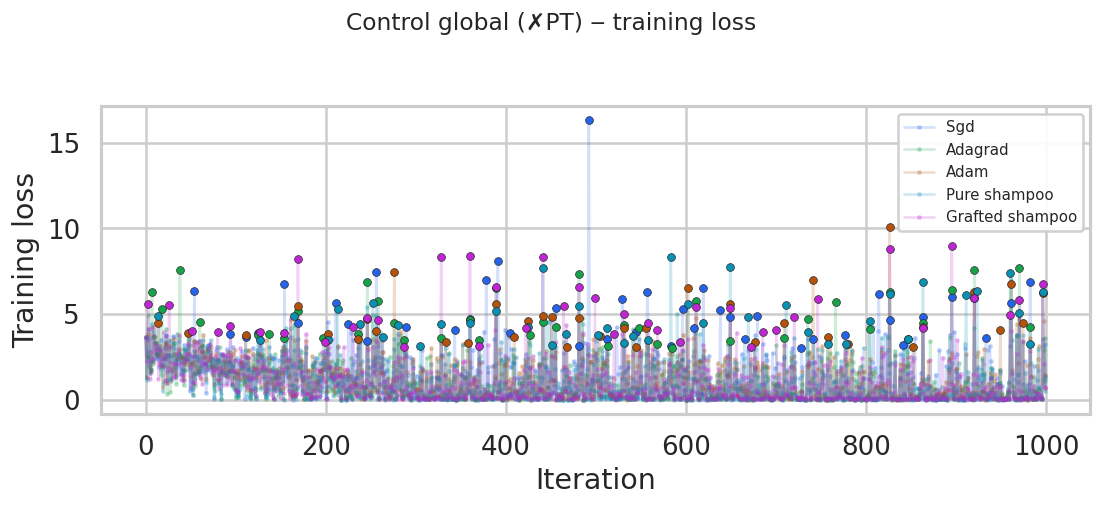

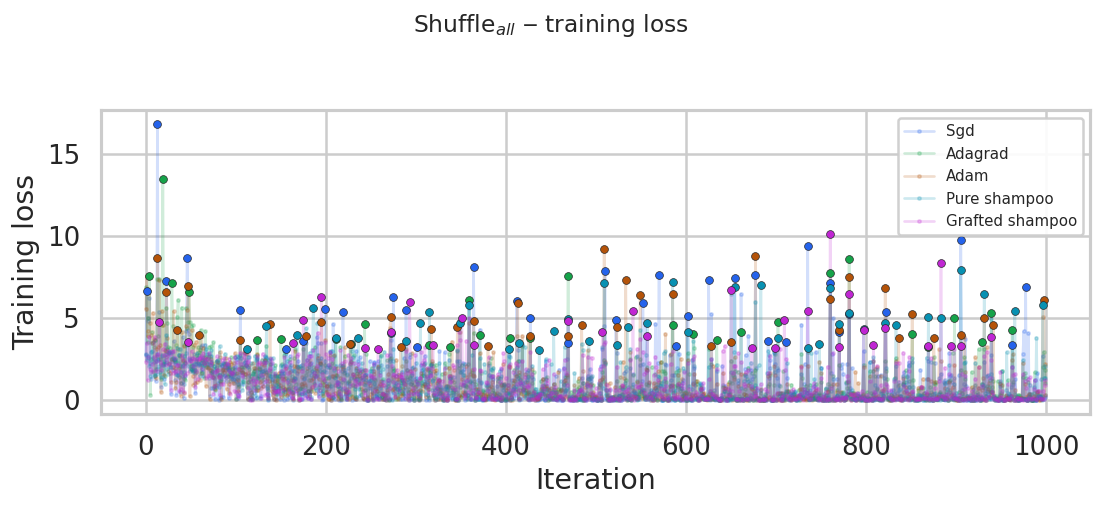

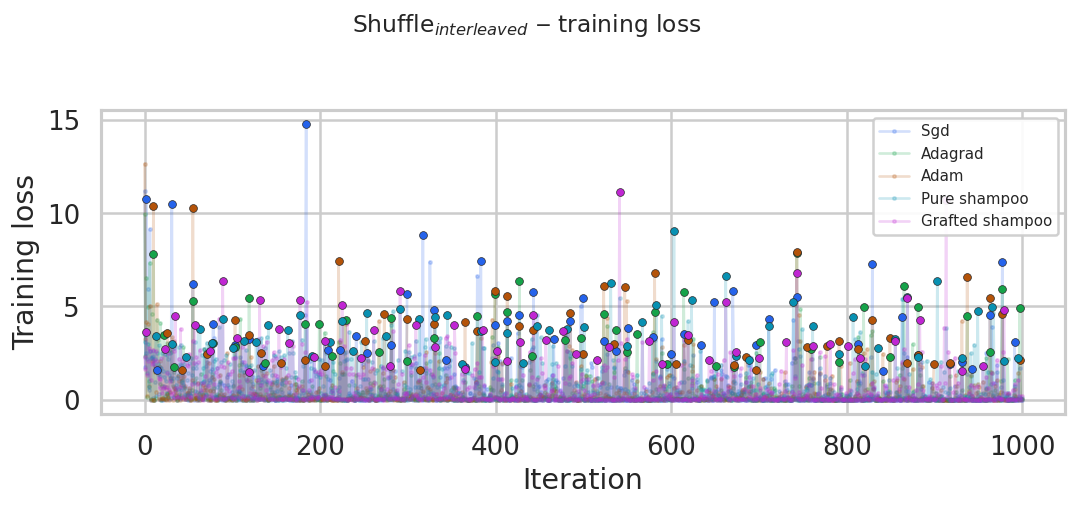

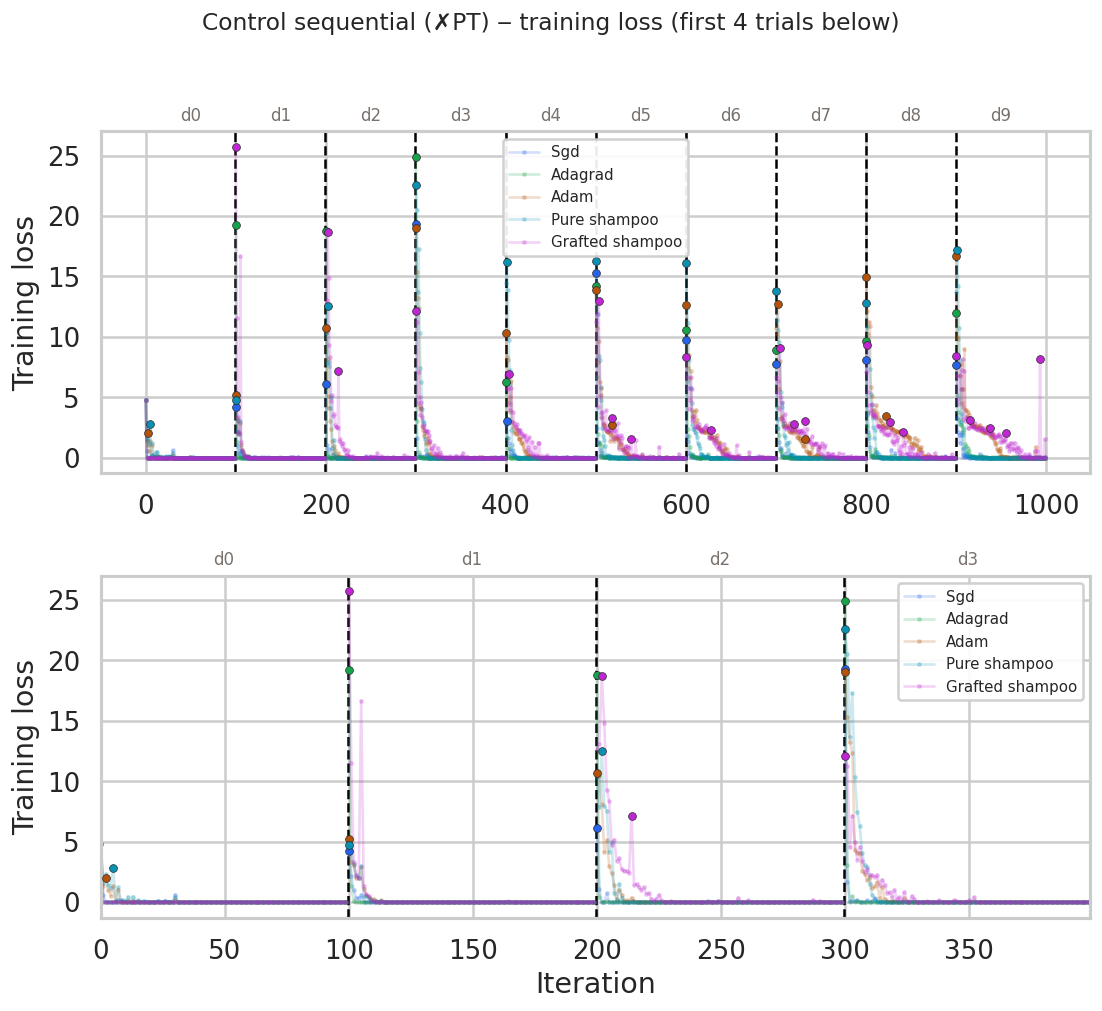

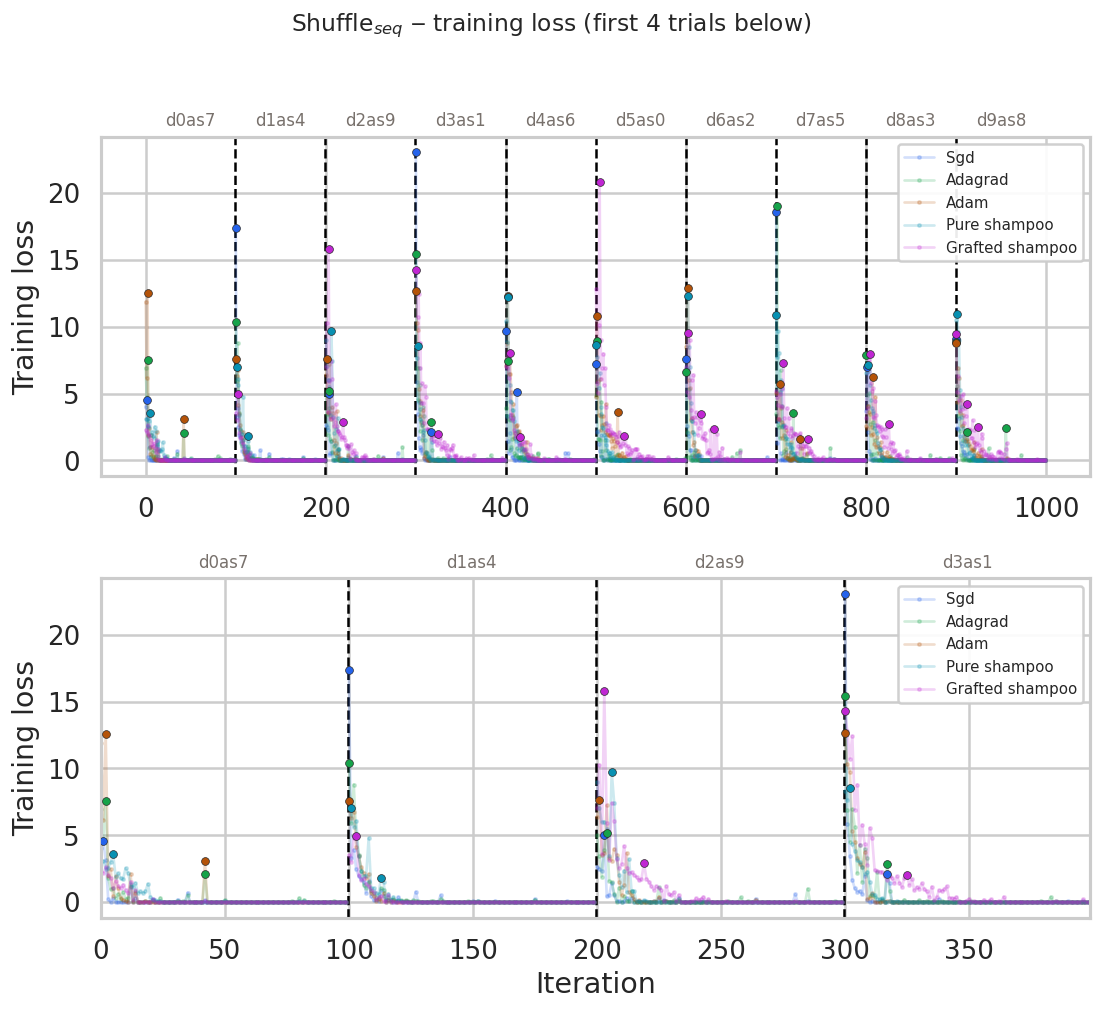

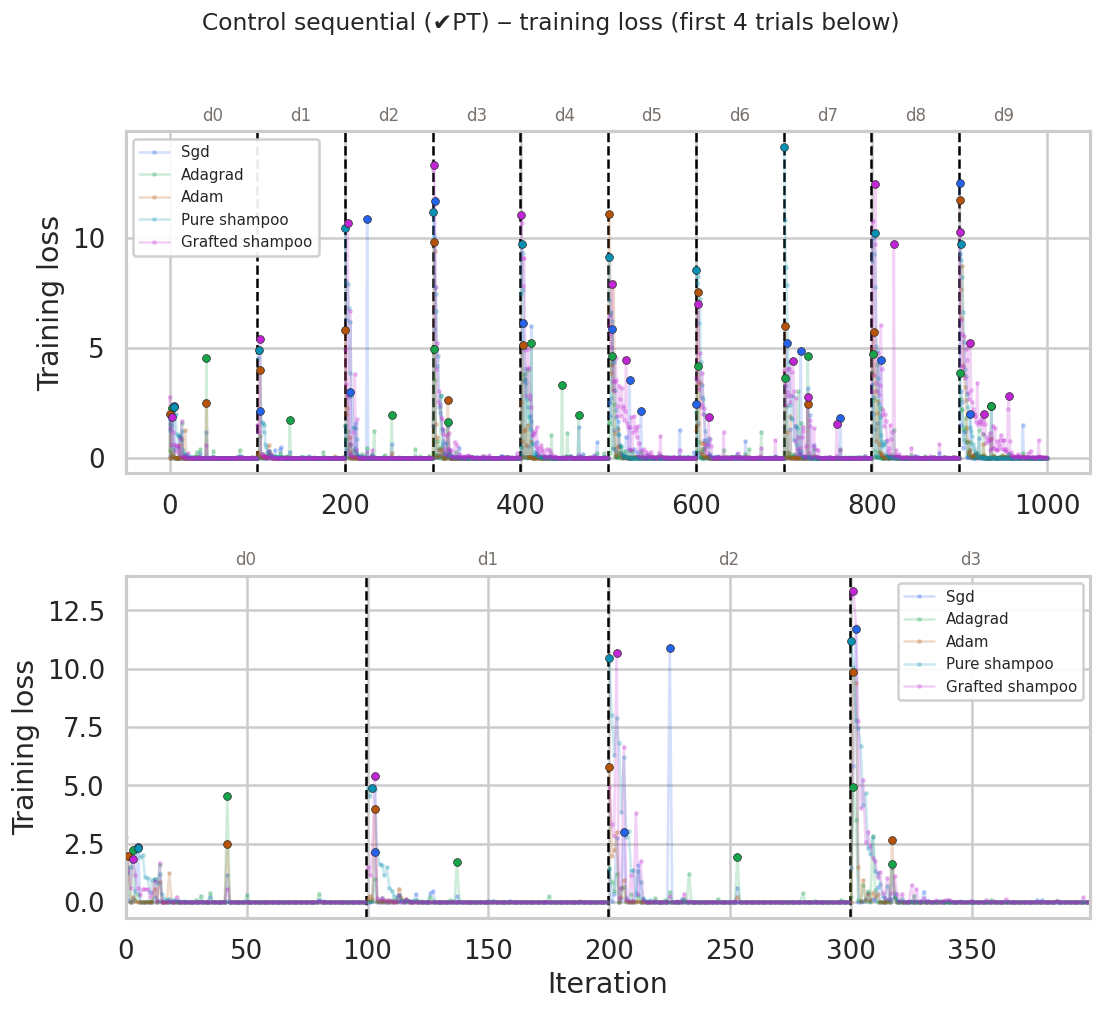

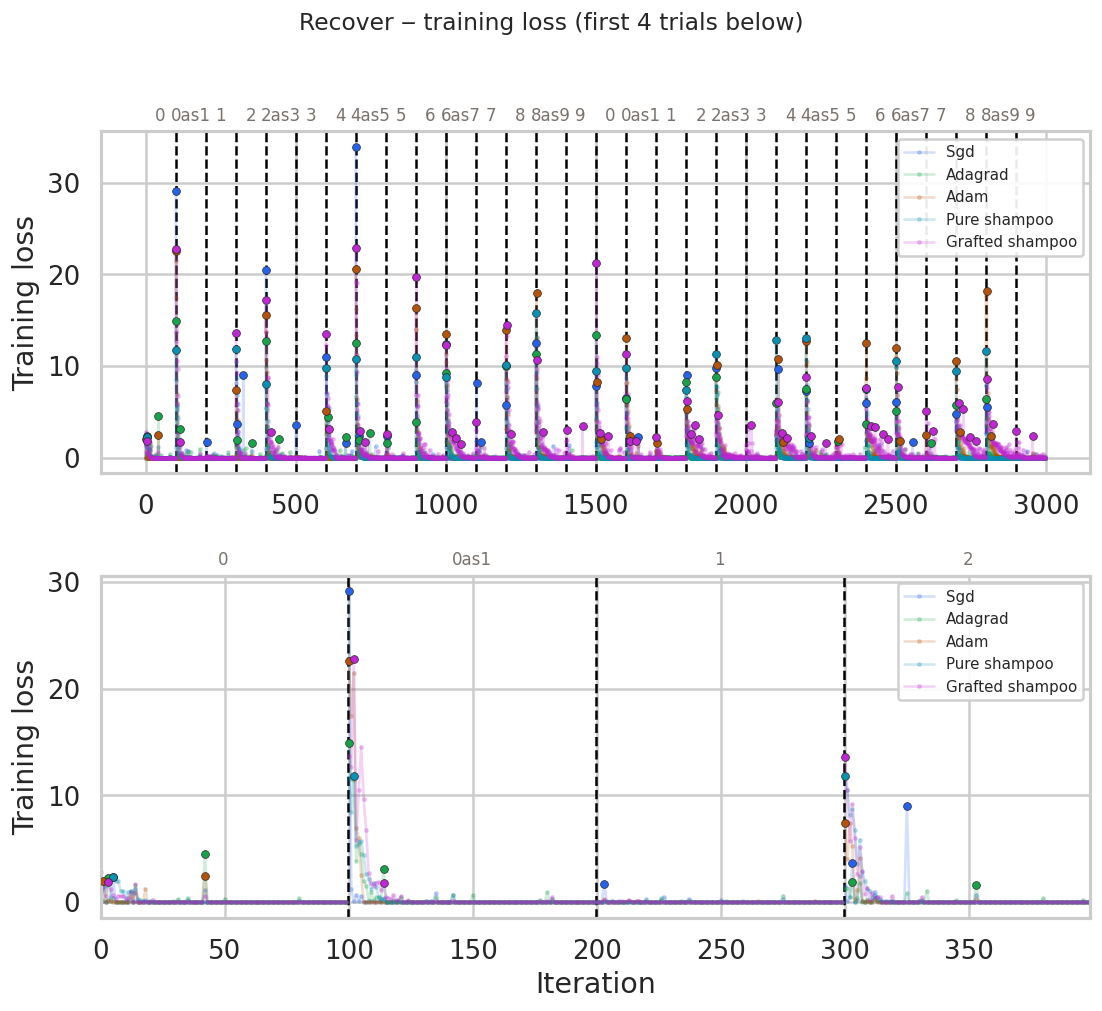

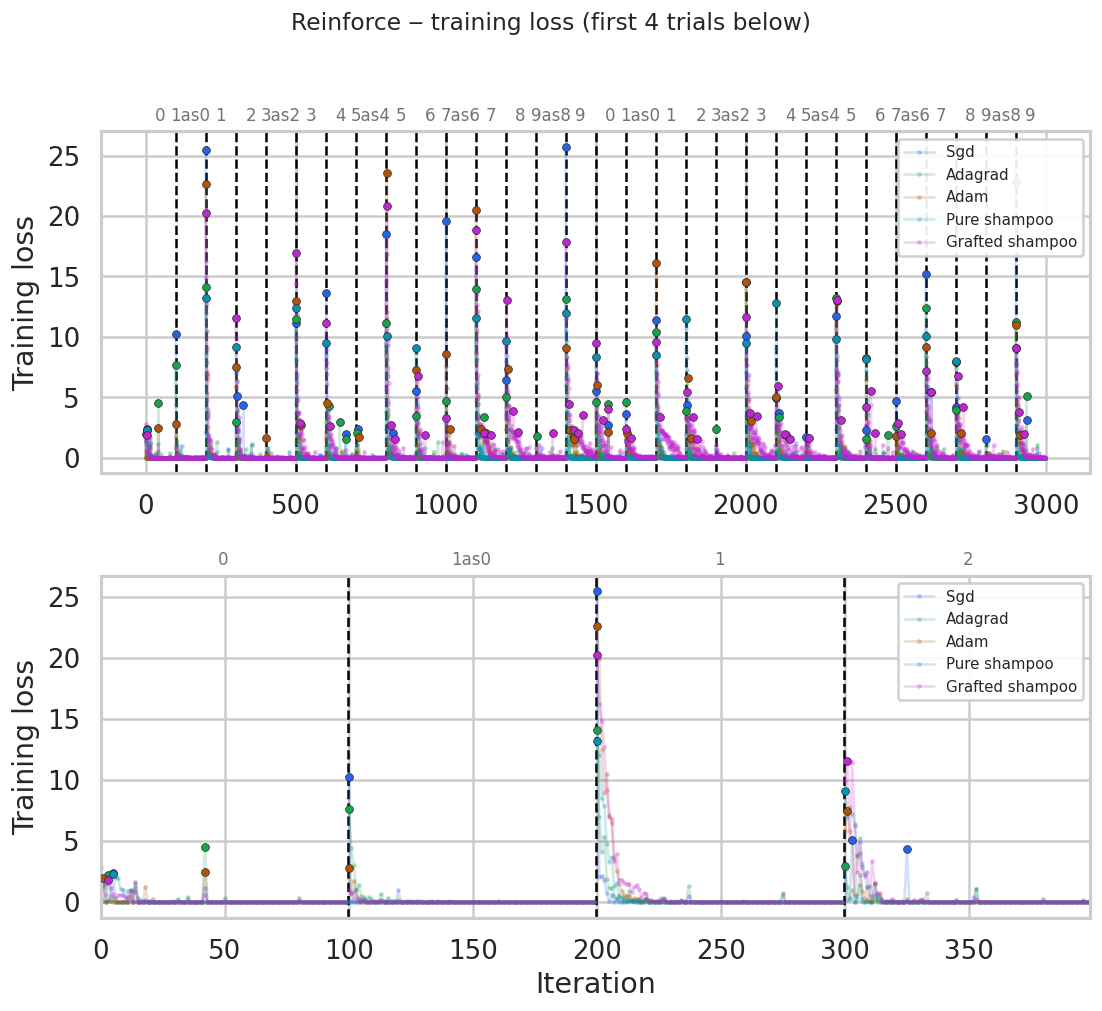

Saved additional_debug_training_loss_peaks_*.pdf


In [4]:
for mid, _arch_slug, filename_suffix, title_suffix in iter_model_plot_contexts(DATASET, all_results):
	sub_results = filter_all_results(all_results, mid)
	sub_tree = filter_tree(tree, mid)
	# Debug: training loss curves + find_peaks markers (tune FIND_PEAKS_KWARGS in setup cell)
	plot_debug_training_loss_peaks(
		sub_tree,
		sub_results,
		rename_fn=rename_experiments,
		plot_dir=PLOT_DIR,
		cat2_early_zoom_n_trials=_CAT2_EARLY_ZOOM_N_TRIALS,
		cat2_early_zoom_max_iter=_CAT2_EARLY_ZOOM_MAX_ITER,
		category_only=True,
		show=True,
		find_peaks_kwargs=FIND_PEAKS_KWARGS,
		find_peaks_kwargs_control_global_shuffle_all=FIND_PEAKS_KWARGS_CONTROLGLOBAL_SHUFFLE_ALL,
		line_alpha=TRAIN_LOSS_LINE_ALPHA,
		peak_marker_size=PEAK_MARKER_SIZE,
		peak_marker_linewidth=PEAK_MARKER_LINEWIDTH,
		filename_suffix=filename_suffix,
		title_suffix=title_suffix,
	)
	print(f"Saved additional_debug_training_loss_peaks_*{filename_suffix}.pdf")


peak_ratio rows (one per peak): 1218
experiment                      optimizer_id          
$\text{Shuffle}_{\{0,1\}}$      adagrad_lr0.01             5
                                adam_lr0.0005              3
                                grafted_shampoo_lr0.01     5
                                pure_shampoo_lr0.01        4
                                sgd_lr0.01                 6
$\text{Shuffle}_{all}$          adagrad_lr0.01            29
                                adam_lr0.0005             39
                                grafted_shampoo_lr0.01    32
                                pure_shampoo_lr0.01       41
                                sgd_lr0.01                35
$\text{Shuffle}_{interleaved}$  adagrad_lr0.01            44
                                adam_lr0.0005             49
                                grafted_shampoo_lr0.01    55
                                pure_shampoo_lr0.01       56
                                sgd_lr0.01            

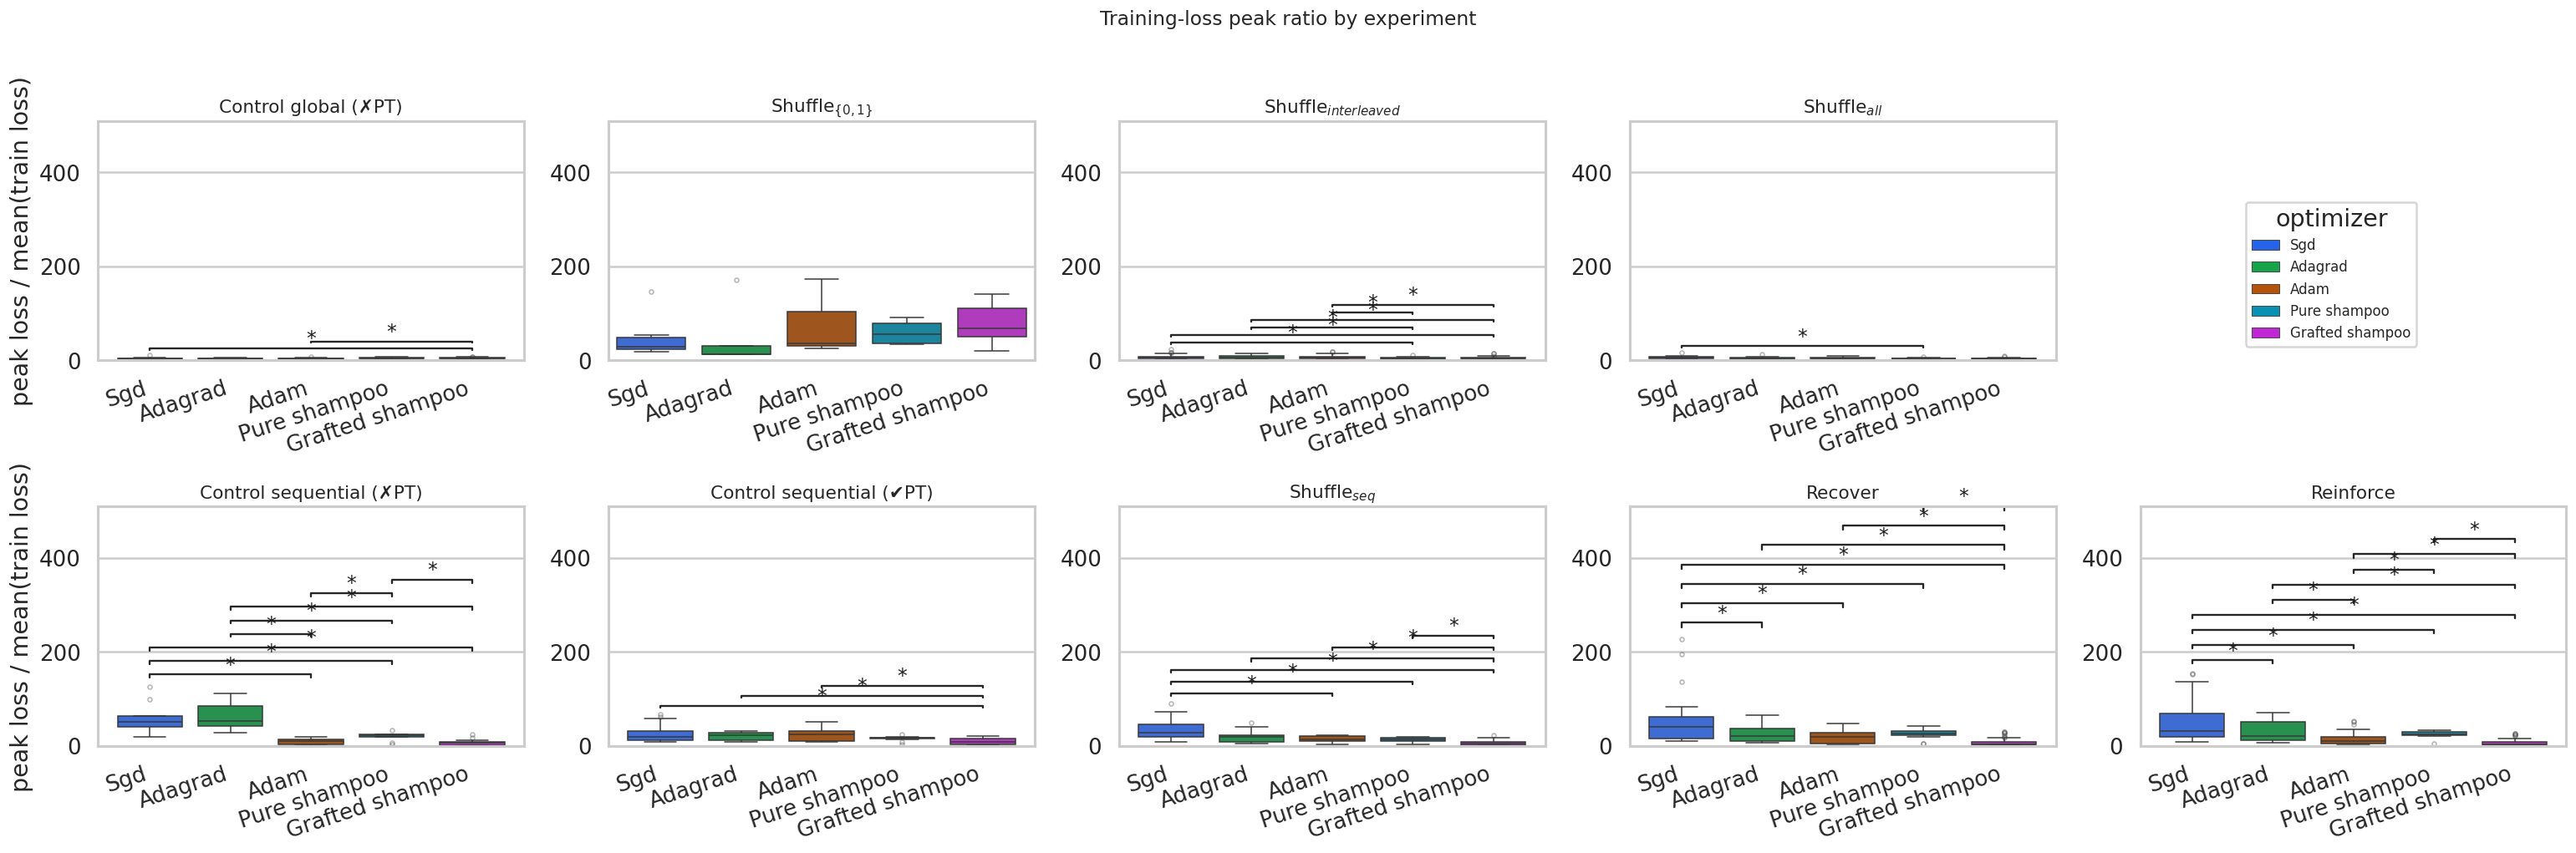

Saved additional_peak_ratio_by_experiment.pdf


In [5]:
for mid, _arch_slug, filename_suffix, title_suffix in iter_model_plot_contexts(DATASET, all_results):
	sub_results = filter_all_results(all_results, mid)
	sub_tree = filter_tree(tree, mid)
	# Peak ratio: one boxplot point per detected peak — (peak loss / mean train loss)
	_fp_label = (
		f"default: {find_peaks_params_label(FIND_PEAKS_KWARGS)}; "
		f"control global / shuffle all: {find_peaks_params_label(FIND_PEAKS_KWARGS_CONTROLGLOBAL_SHUFFLE_ALL)}"
	)
	df_peak = build_peak_ratio_df(
		sub_tree,
		rename_fn=rename_experiments,
		category_only=True,
		find_peaks_kwargs=FIND_PEAKS_KWARGS,
		find_peaks_kwargs_control_global_shuffle_all=FIND_PEAKS_KWARGS_CONTROLGLOBAL_SHUFFLE_ALL,
	)
	print(f"peak_ratio rows (one per peak): {len(df_peak)}")
	if not df_peak.empty:
		print(df_peak.groupby(["experiment", "optimizer_id"]).size().to_string())
		print_peak_ratio_pooled_summaries(
			df_peak,
			labels=LABELS,
			sort_experiment_names=_sort_experiment_display_names,
		)

	if not df_peak.empty:
		ylim = _fixed_ylim_for_metric(
			df_peak,
			"peak_ratio",
			"experiment",
			sort_experiment_names=_sort_experiment_display_names,
			sig_bracket_ylim_pad_frac=SIG_BRACKET_YLIM_PAD_FRAC,
		)
		facet_box_welch_cat12(
			df_peak,
			"peak_ratio",
			"experiment",
			f"Training-loss peak ratio by experiment",# (find_peaks: {_fp_label})",
			r"peak loss / mean(train loss)",
			with_arch_filename("additional_peak_ratio_by_experiment.pdf", filename_suffix),
			fixed_ylim=ylim,
			show=True,
			**_PLOT_KW,
		)
		print(f"Saved {with_arch_filename('additional_peak_ratio_by_experiment.pdf', filename_suffix)}")
	else:
		print(f"df_peak empty — skip peak-ratio plot{title_suffix}")


/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/io.py:57: DtypeWarning: Columns (0: layer_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(str(path))


btsp neuron-% rows (per run/layer): 222

Control global (✗PT) — per-optimizer slopes (/layer):
  Sgd: +7.8125  (R²=0.701)
  Adagrad: +7.8125  (R²=0.575)
  Adam: +2.3438  (R²=0.771)
  Pure shampoo: +4.8438  (R²=0.867)
  Grafted shampoo: -0.6250  (R²=0.500)

$\text{Shuffle}_{\{0,1\}}$ — per-optimizer slopes (/layer):
  Sgd: +0.9375  (R²=0.900)
  Adagrad: +0.0000  (R²=0.000)
  Adam: +0.3125  (R²=0.143)
  Pure shampoo: +2.0312  (R²=0.939)
  Grafted shampoo: +1.5625  (R²=0.532)

$\text{Shuffle}_{interleaved}$ — per-optimizer slopes (/layer):
  Sgd: +3.9062  (R²=0.601)
  Adagrad: +0.3125  (R²=0.500)
  Adam: +2.1875  (R²=0.383)
  Pure shampoo: +2.3438  (R²=0.938)
  Grafted shampoo: +3.4375  (R²=0.917)

$\text{Shuffle}_{all}$ — per-optimizer slopes (/layer):
  Sgd: +5.6250  (R²=0.973)
  Adagrad: +0.9375  (R²=0.750)
  Adam: -0.1562  (R²=0.005)
  Pure shampoo: +2.5000  (R²=0.889)
  Grafted shampoo: +3.4375  (R²=0.818)

Control sequential (✗PT) — per-optimizer slopes (/layer):
  Sgd: +6.5625  (R²

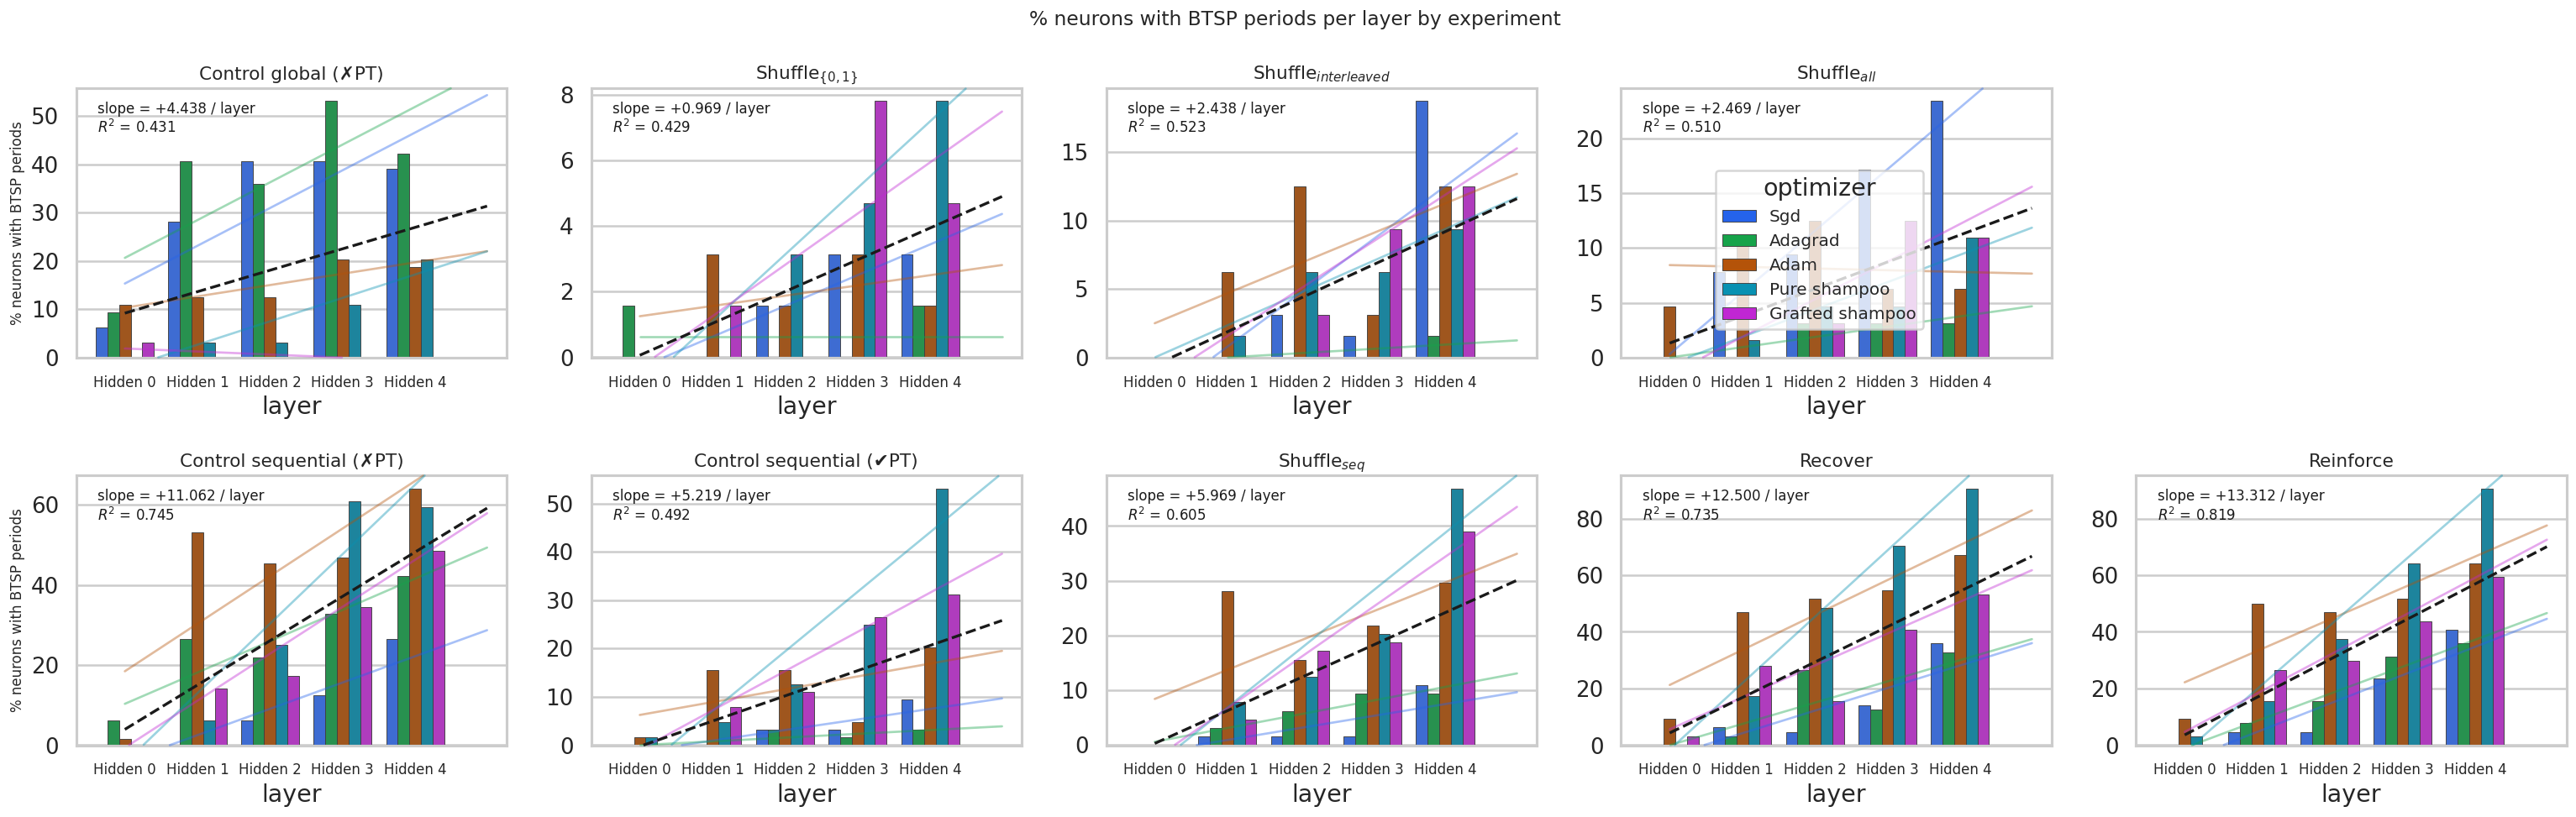

Saved additional_btsp_neuron_pct_per_layer_by_experiment.pdf


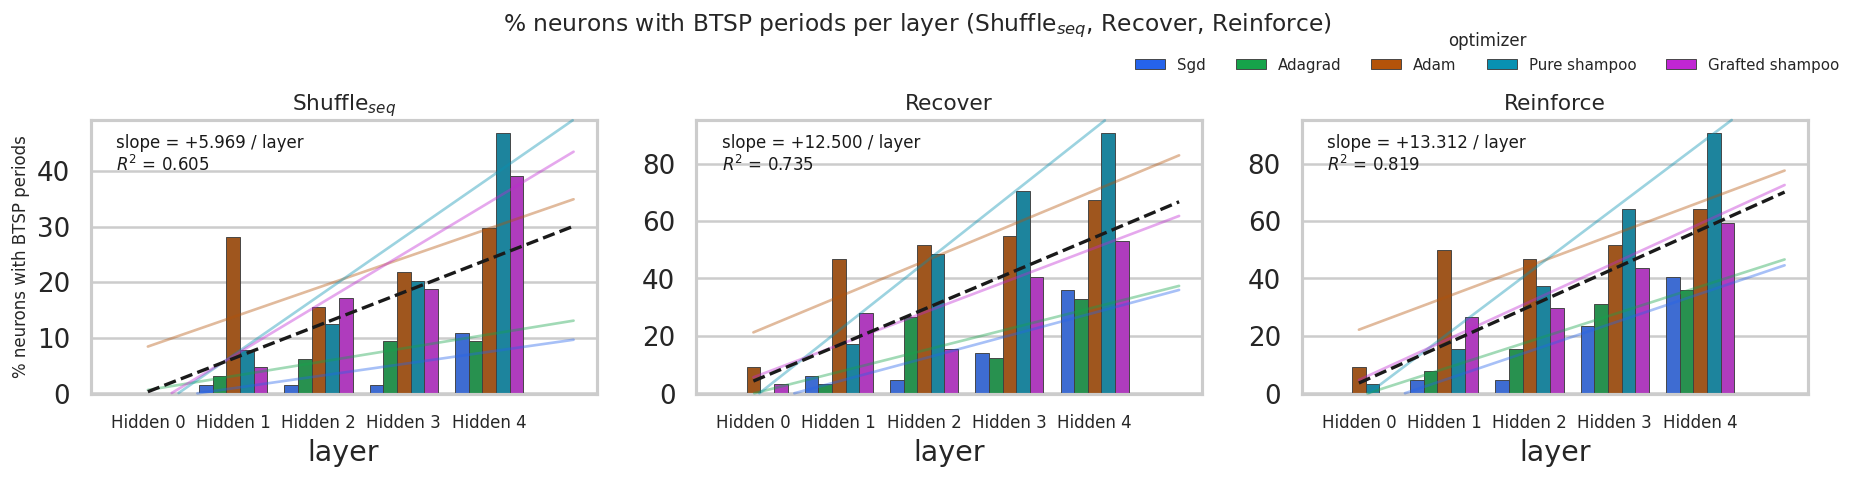

Saved additional_btsp_neuron_pct_per_layer_shuffle_recover_reinforce.pdf


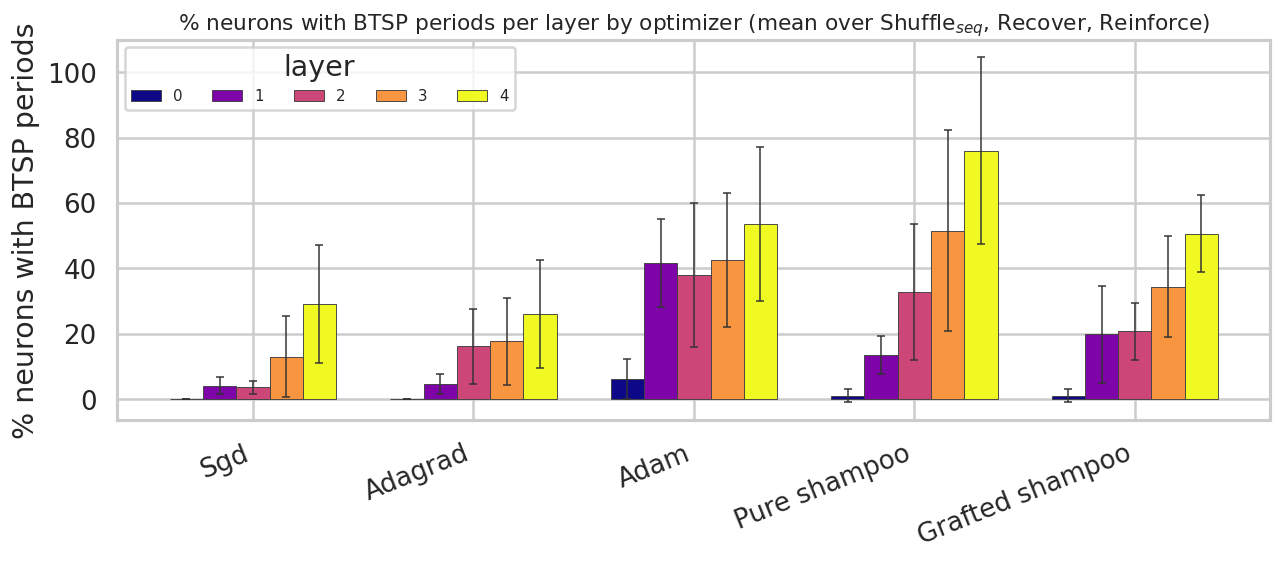

Saved additional_btsp_neuron_pct_per_layer_pooled_shuffle_recover_reinforce.pdf

=== LaTeX table (neuron % slopes/R²) ===
In \cref{tab:neuron_pct_slopes_r2}, you can find the slopes and $R^2$ values for each optimizer and layer.
\begin{table}[ht]
\centering
\ra{1.3}
\resizebox{0.95\textwidth}{!}{%
\begin{tabular}{l cc cc cc cc cc cc cc cc cc}
\toprule
\textbf{Optimizer} & \multicolumn{2}{c}{\textbf{Ctrl. global (\xmark PT)}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{\{0,1\}}$}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{interleaved}$}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{all}$}} & \multicolumn{2}{c}{\textbf{Ctrl. seq. (\xmark PT)}} & \multicolumn{2}{c}{\textbf{Ctrl. seq. (\cmark PT)}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{seq}$}} & \multicolumn{2}{c}{\textbf{Recover}} & \multicolumn{2}{c}{\textbf{Reinforce}} \\
\midrule
 & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \tex

In [6]:
for mid, _arch_slug, filename_suffix, title_suffix in iter_model_plot_contexts(DATASET, all_results):
	sub_results = filter_all_results(all_results, mid)
	# BTSP: % neurons per layer with at least one BTSP period (hidden layers only)
	df_btsp_pct = build_btsp_neuron_pct_rows(sub_results, rename_experiments)
	df_btsp_pct = df_btsp_pct[df_btsp_pct["layer_name"].astype(str) != "head"]
	print(f"btsp neuron-% rows (per run/layer): {len(df_btsp_pct)}")

	_POOL_EXPS = cat2_shuffle_recover_reinforce_labels(LABELS)
	_POOL_TITLE_SUFFIX = f"mean over {LABELS.shuffle_seq}, Recover, Reinforce"
	per_layer_regressions = {}

	if not df_btsp_pct.empty:
		agg_btsp_pct = (
			df_btsp_pct.groupby(["experiment", "layer_name", "optimizer_id"], observed=False)[
				"pct_btsp_neurons"
			]
			.mean()
			.reset_index()
		)
		fig_btsp, _axes_btsp, plotted_btsp = facet_bar_by_experiment_cat12(
			agg_btsp_pct,
			"experiment",
			"pct_btsp_neurons",
			"% neurons with BTSP periods per layer by experiment",
			"% neurons with BTSP periods",
			with_arch_filename("additional_btsp_neuron_pct_per_layer_by_experiment.pdf", filename_suffix),
			plot_dir=PLOT_DIR,
			sort_experiment_names=_sort_experiment_display_names,
			labels=LABELS,
			show=False,
			save=False,
		)
		if fig_btsp is not None:
			for ax, exp in plotted_btsp:
				sub = agg_btsp_pct[agg_btsp_pct["experiment"] == exp]
				order_layers = _sort_layer_display_names(sub["layer_name"].unique())
				overlay_layer_group_mean_regression(
					ax, sub, order_layers, "pct_btsp_neurons"
				)
				opt_slopes = overlay_layer_per_optimizer_regression(
					ax, sub, order_layers, "pct_btsp_neurons"
				)
				if opt_slopes:
					print(f"\n{exp} — per-optimizer slopes (/layer):")
					for oid, (slope, r2) in opt_slopes.items():
						print(f"  {_opt_display(oid)}: {slope:+.4f}  (R²={r2:.3f})")
					per_layer_regressions[exp] = opt_slopes
				

			fig_btsp.savefig(Path(PLOT_DIR) / with_arch_filename("additional_btsp_neuron_pct_per_layer_by_experiment.pdf", filename_suffix), bbox_inches="tight")
			plt.show(fig_btsp)
			print(f"Saved {with_arch_filename('additional_btsp_neuron_pct_per_layer_by_experiment.pdf', filename_suffix)}")

		agg_btsp_cat2 = agg_btsp_pct[agg_btsp_pct["experiment"].astype(str).isin(_POOL_EXPS)]
		fig_btsp_cat2, _axes_cat2, plotted_cat2 = facet_bar_by_experiment_row(
			agg_btsp_cat2,
			"experiment",
			_POOL_EXPS,
			"pct_btsp_neurons",
			f"% neurons with BTSP periods per layer ({LABELS.shuffle_seq}, Recover, Reinforce)",
			"% neurons with BTSP periods",
			with_arch_filename("additional_btsp_neuron_pct_per_layer_shuffle_recover_reinforce.pdf", filename_suffix),
			plot_dir=PLOT_DIR,
			show=False,
			save=False,
		)
		if fig_btsp_cat2 is not None:
			for ax, exp in plotted_cat2:
				sub = agg_btsp_cat2[agg_btsp_cat2["experiment"] == exp]
				order_layers = _sort_layer_display_names(sub["layer_name"].unique())
				overlay_layer_group_mean_regression(
					ax, sub, order_layers, "pct_btsp_neurons"
				)
				overlay_layer_per_optimizer_regression(
					ax, sub, order_layers, "pct_btsp_neurons"
				)

			fig_btsp_cat2.savefig(
				Path(PLOT_DIR)
				/ with_arch_filename("additional_btsp_neuron_pct_per_layer_shuffle_recover_reinforce.pdf", filename_suffix),
				bbox_inches="tight",
			)
			plt.show(fig_btsp_cat2)
			print(f"Saved {with_arch_filename('additional_btsp_neuron_pct_per_layer_shuffle_recover_reinforce.pdf', filename_suffix)}")

		agg_pooled_neuron = pool_btsp_mean_over_experiments(
			agg_btsp_pct, "experiment", _POOL_EXPS, "pct_btsp_neurons"
		)
		if not agg_pooled_neuron.empty:
			plot_btsp_pooled_optimizer_layer_bars(
				agg_pooled_neuron,
				"pct_btsp_neurons",
				"% neurons with BTSP periods",
				f"% neurons with BTSP periods per layer by optimizer ({_POOL_TITLE_SUFFIX})",
				with_arch_filename("additional_btsp_neuron_pct_per_layer_pooled_shuffle_recover_reinforce.pdf", filename_suffix),
				plot_dir=PLOT_DIR,
				show=True,
				save=True,
			)
			print(
				f"Saved {with_arch_filename('additional_btsp_neuron_pct_per_layer_pooled_shuffle_recover_reinforce.pdf', filename_suffix)}"
			)
	else:
		print(f"df_btsp_pct empty — skip BTSP neuron-% plot{title_suffix}")


	if per_layer_regressions:
		print(f"\n=== LaTeX table (neuron % slopes/R²){title_suffix} ===")
		print(r"In \cref{tab:neuron_pct_slopes_r2}, you can find the slopes and $R^2$ values for each optimizer and layer.")
		latex_table, latex_best_r2_slope = build_latex_table(per_layer_regressions, ref_name="neuron_pct_slopes_r2")
		print(latex_table)
		print()
		print(latex_best_r2_slope)


score-per-period rows (for layer bar SEM): 2929
score-per-run/layer rows (for across-layer printout): 174
Mean total score across layers (per experiment × optimizer):

Control global (✗PT)
  Sgd: 0.9649
  Adagrad: 1.0509
  Adam: 1.0819
  Pure shampoo: 1.0382
  Grafted shampoo: 1.7252
  experiment mean (all periods): 0.9601

$\text{Shuffle}_{\{0,1\}}$
  Sgd: 0.9642
  Adagrad: 1.5555
  Adam: 1.5616
  Pure shampoo: 1.4865
  Grafted shampoo: 1.2815
  experiment mean (all periods): 1.3592

$\text{Shuffle}_{interleaved}$
  Sgd: 0.9299
  Adagrad: 0.9585
  Adam: 0.9882
  Pure shampoo: 1.0746
  Grafted shampoo: 1.2117
  experiment mean (all periods): 1.0039

$\text{Shuffle}_{all}$
  Sgd: 0.9733
  Adagrad: 0.8248
  Adam: 1.1326
  Pure shampoo: 1.0194
  Grafted shampoo: 0.9769
  experiment mean (all periods): 0.9656

Control sequential (✗PT)
  Sgd: 1.6213
  Adagrad: 1.8025
  Adam: 1.4139
  Pure shampoo: 1.4985
  Grafted shampoo: 1.3524
  experiment mean (all periods): 1.4445

Control sequential (

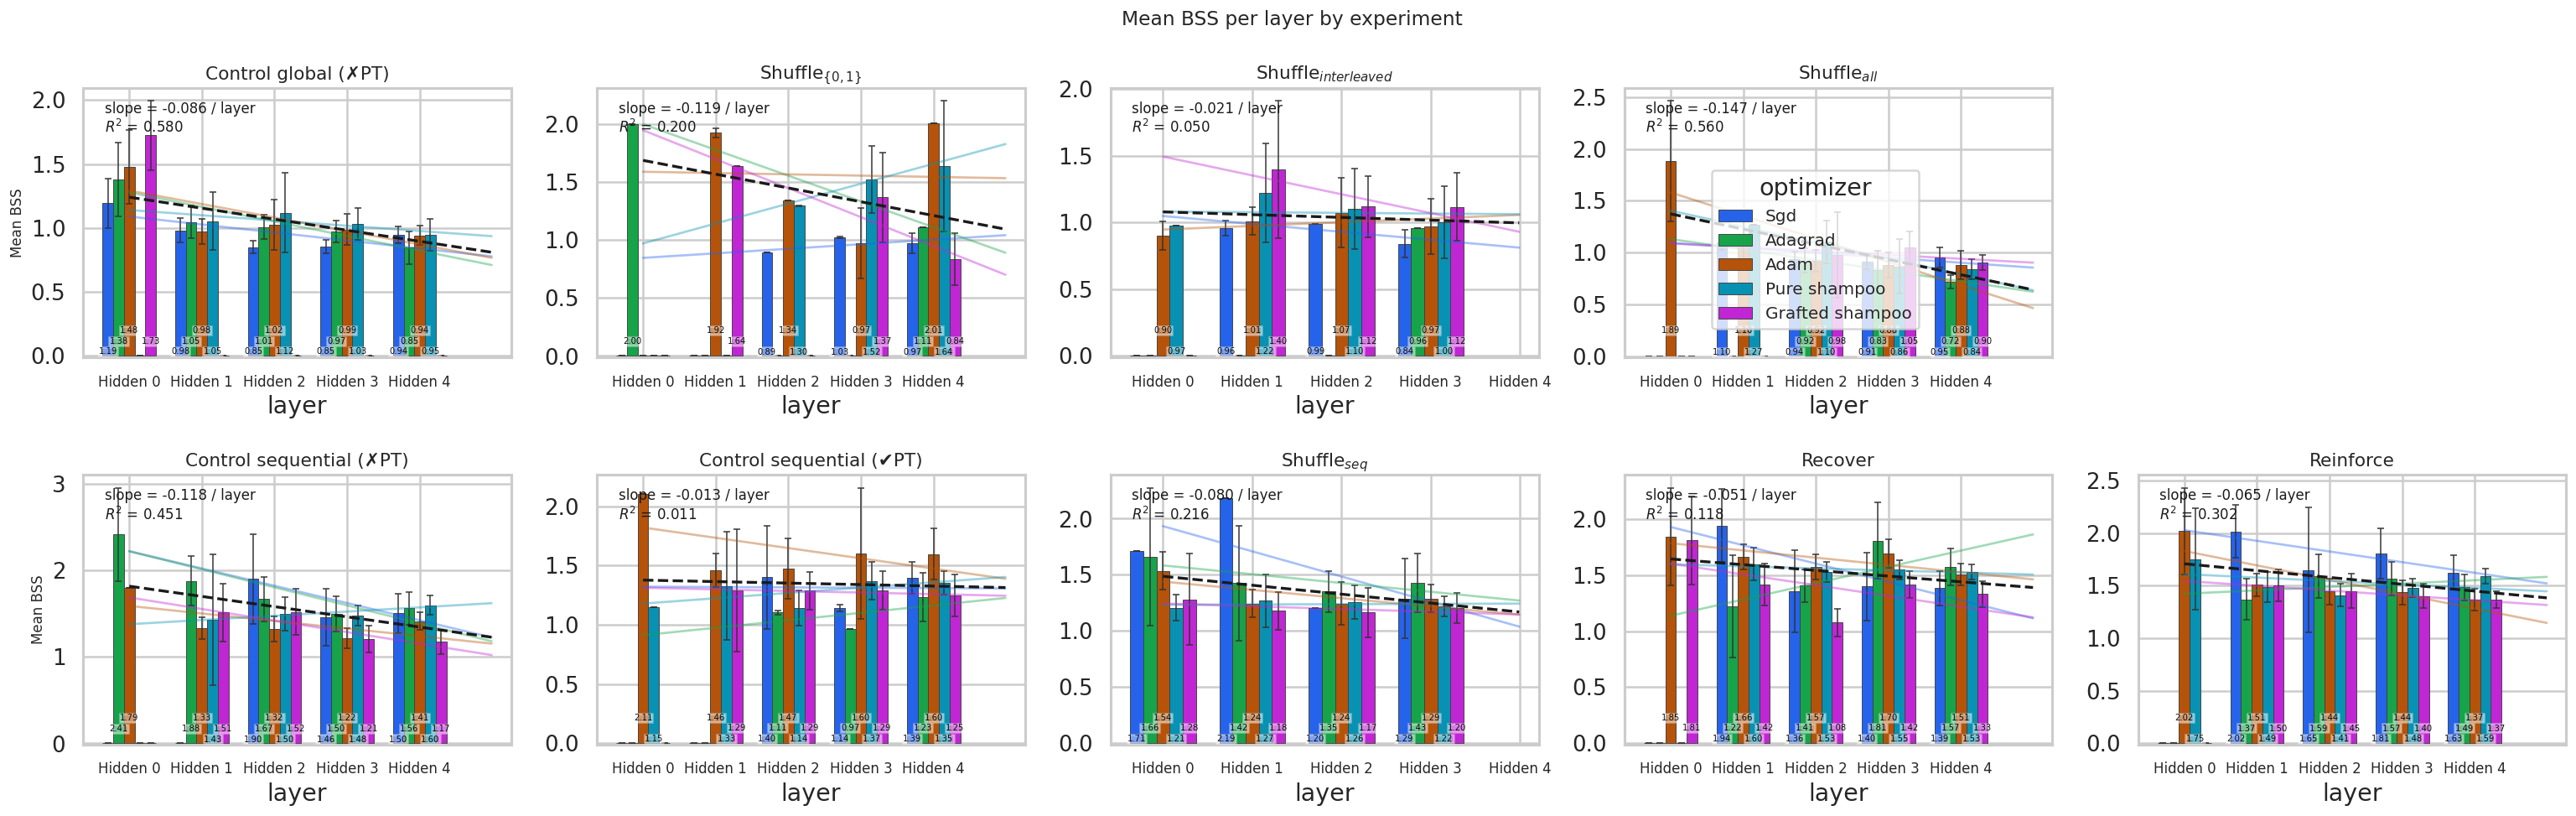

Saved additional_mean_score_per_layer_by_experiment.pdf


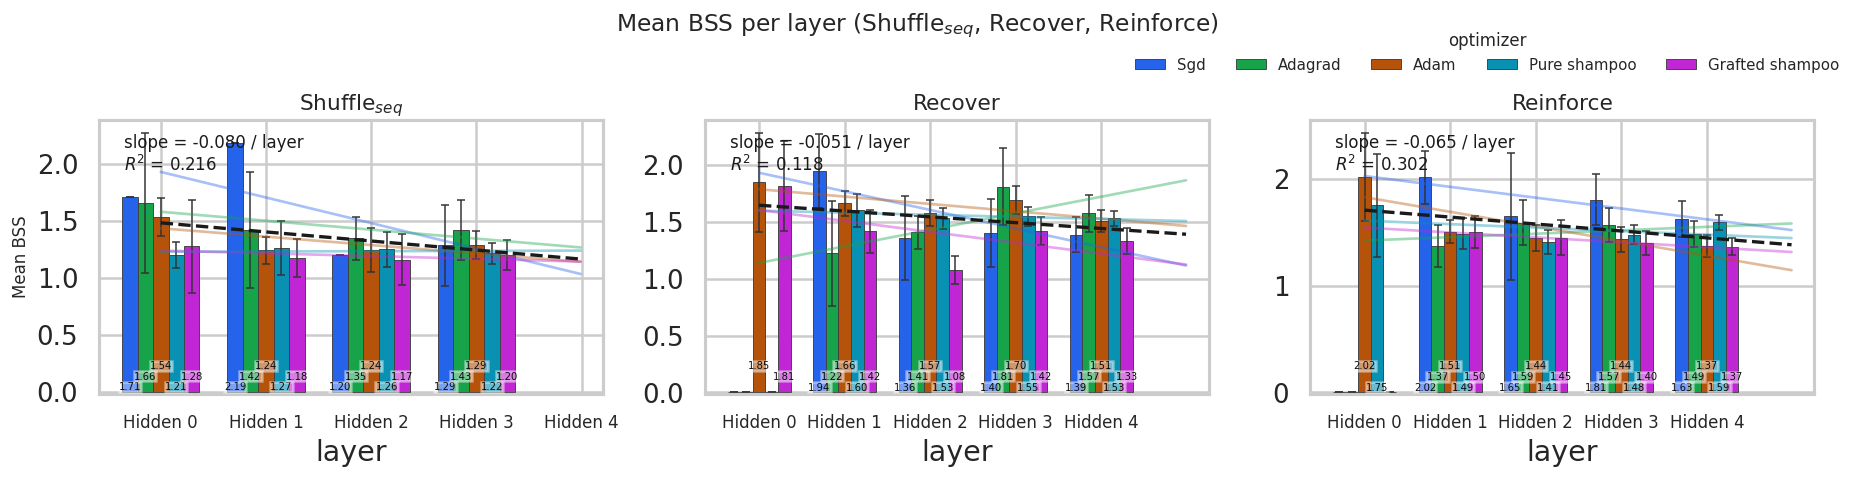

Saved additional_mean_score_per_layer_shuffle_recover_reinforce.pdf


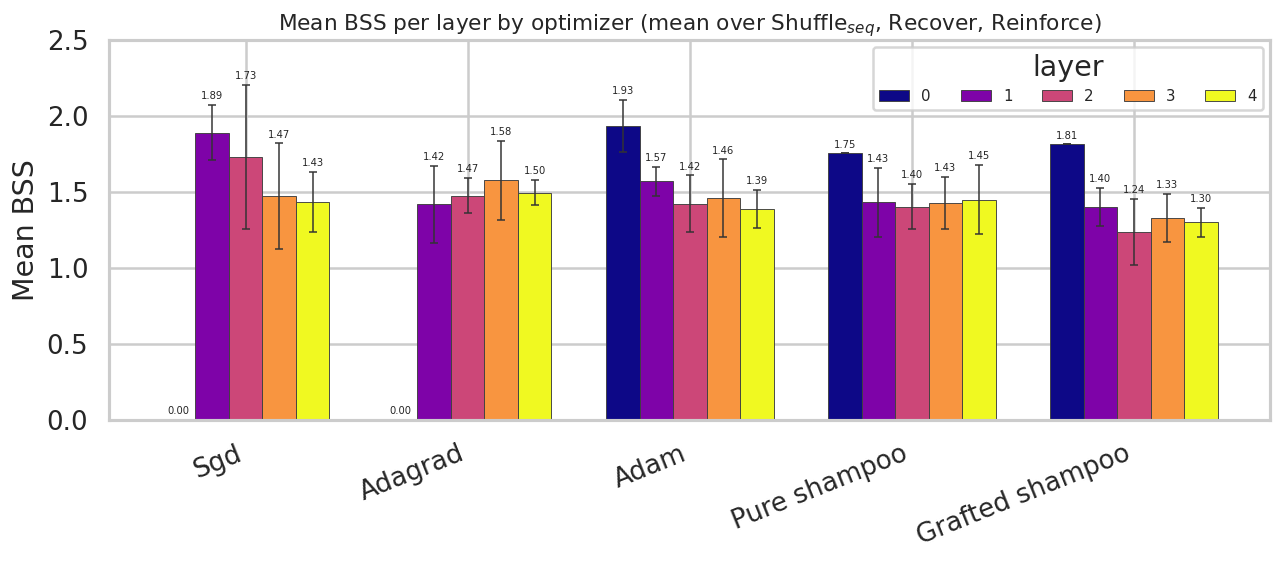

Saved additional_mean_score_per_layer_pooled_shuffle_recover_reinforce.pdf

=== LaTeX table (BSS slopes/R²) ===
In \cref{tab:bss_slopes_r2}, you can find the slopes and $R^2$ values for each optimizer and layer.
\begin{table}[ht]
\centering
\ra{1.3}
\resizebox{0.95\textwidth}{!}{%
\begin{tabular}{l cc cc cc cc cc cc cc cc cc}
\toprule
\textbf{Optimizer} & \multicolumn{2}{c}{\textbf{Ctrl. global (\xmark PT)}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{\{0,1\}}$}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{interleaved}$}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{all}$}} & \multicolumn{2}{c}{\textbf{Ctrl. seq. (\xmark PT)}} & \multicolumn{2}{c}{\textbf{Ctrl. seq. (\cmark PT)}} & \multicolumn{2}{c}{\textbf{$\text{Shuffle}_{seq}$}} & \multicolumn{2}{c}{\textbf{Recover}} & \multicolumn{2}{c}{\textbf{Reinforce}} \\
\midrule
 & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \textbf{$R^2$} & \textbf{Slope} & \tex

In [7]:
for mid, _arch_slug, filename_suffix, title_suffix in iter_model_plot_contexts(DATASET, all_results):
	sub_results = filter_all_results(all_results, mid)
	# Score per layer: mean total_score across periods (hidden layers only), ±1.96 SEM
	df_score_periods = build_layer_period_score_rows(sub_results, rename_experiments)
	df_score_periods = df_score_periods[df_score_periods["layer_name"].astype(str) != "head"]
	print(f"score-per-period rows (for layer bar SEM): {len(df_score_periods)}")

	df_score_layer = build_layer_mean_score_rows(sub_results, rename_experiments)
	df_score_layer = df_score_layer[df_score_layer["layer_name"].astype(str) != "head"]
	print(f"score-per-run/layer rows (for across-layer printout): {len(df_score_layer)}")

	print_mean_score_across_layers(
		df_score_layer,
		labels=LABELS,
		period_df=df_score_periods,
		sort_experiment_names=_sort_experiment_display_names,
	)

	_POOL_EXPS_SCORE = cat2_shuffle_recover_reinforce_labels(LABELS)
	_POOL_TITLE_SUFFIX_SCORE = f"mean over {LABELS.shuffle_seq}, Recover, Reinforce"
	score_per_layer_regressions = {}

	if not df_score_periods.empty:
		agg_score = aggregate_layer_metric_mean_sem(
			df_score_periods,
			["experiment", "layer_name", "optimizer_id"],
			"total_score",
		)
		fig_score, _axes_score, plotted_score = facet_bar_by_experiment_cat12(
			agg_score,
			"experiment",
			"total_score",
			"Mean BSS per layer by experiment",
			"Mean BSS",
			with_arch_filename("additional_mean_score_per_layer_by_experiment.pdf", filename_suffix),
			plot_dir=PLOT_DIR,
			sort_experiment_names=_sort_experiment_display_names,
			labels=LABELS,
			sem_col="sem",
			annotate_bars=True,
			annotate_bars_inside=True,
			show=False,
			save=False,
		)
		if fig_score is not None:
			for ax, exp in plotted_score:
				sub = agg_score[agg_score["experiment"] == exp]
				order_layers = _sort_layer_display_names(sub["layer_name"].unique())
				overlay_layer_group_mean_regression(
					ax, sub, order_layers, "total_score", fill_missing_layers=False
				)
				score_opt_slopes = overlay_layer_per_optimizer_regression(
					ax, sub, order_layers, "total_score", fill_missing_layers=False
				)
				score_per_layer_regressions[exp] = score_opt_slopes
		
			fig_score.savefig(
				Path(PLOT_DIR) / with_arch_filename("additional_mean_score_per_layer_by_experiment.pdf", filename_suffix),
				bbox_inches="tight",
			)
			plt.show(fig_score)
			print(f"Saved {with_arch_filename('additional_mean_score_per_layer_by_experiment.pdf', filename_suffix)}")

		agg_score_cat2 = agg_score[agg_score["experiment"].astype(str).isin(_POOL_EXPS_SCORE)]
		fig_score_cat2, _axes_score_cat2, plotted_score_cat2 = facet_bar_by_experiment_row(
			agg_score_cat2,
			"experiment",
			_POOL_EXPS_SCORE,
			"total_score",
			f"Mean BSS per layer ({LABELS.shuffle_seq}, Recover, Reinforce)",
			"Mean BSS",
			with_arch_filename("additional_mean_score_per_layer_shuffle_recover_reinforce.pdf", filename_suffix),
			plot_dir=PLOT_DIR,
			sem_col="sem",
			annotate_bars=True,
			annotate_bars_inside=True,
			show=False,
			save=False,
		)
		if fig_score_cat2 is not None:
			for ax, exp in plotted_score_cat2:
				sub = agg_score_cat2[agg_score_cat2["experiment"] == exp]
				order_layers = _sort_layer_display_names(sub["layer_name"].unique())
				overlay_layer_group_mean_regression(
					ax, sub, order_layers, "total_score", fill_missing_layers=False
				)
				overlay_layer_per_optimizer_regression(
					ax, sub, order_layers, "total_score", fill_missing_layers=False
				)
			fig_score_cat2.savefig(
				Path(PLOT_DIR)
				/ with_arch_filename("additional_mean_score_per_layer_shuffle_recover_reinforce.pdf", filename_suffix),
				bbox_inches="tight",
			)
			plt.show(fig_score_cat2)
			print(f"Saved {with_arch_filename('additional_mean_score_per_layer_shuffle_recover_reinforce.pdf', filename_suffix)}")

		agg_pooled_score = pool_btsp_mean_over_experiments(
			agg_score, "experiment", _POOL_EXPS_SCORE, "total_score"
		)
		if not agg_pooled_score.empty:
			plot_btsp_pooled_optimizer_layer_bars(
				agg_pooled_score,
				"total_score",
				"Mean BSS",
				f"Mean BSS per layer by optimizer ({_POOL_TITLE_SUFFIX_SCORE})",
				with_arch_filename("additional_mean_score_per_layer_pooled_shuffle_recover_reinforce.pdf", filename_suffix),
				plot_dir=PLOT_DIR,
				annotate_bars=True,
				annotate_bars_inside=False,
				show=True,
				save=True,
			)
			print(
				f"Saved {with_arch_filename('additional_mean_score_per_layer_pooled_shuffle_recover_reinforce.pdf', filename_suffix)}"
			)
	else:
		print(f"df_score_periods empty — skip score-per-layer plots{title_suffix}")

	if score_per_layer_regressions:
		print(f"\n=== LaTeX table (BSS slopes/R²){title_suffix} ===")
		print(r"In \cref{tab:bss_slopes_r2}, you can find the slopes and $R^2$ values for each optimizer and layer.")
		score_latex_table, score_latex_best_r2_slope = build_latex_table(score_per_layer_regressions, ref_name="bss_slopes_r2")
		print(score_latex_table)
		print()
		print(score_latex_best_r2_slope)


btsp cumulative segment rows (model/optimizer/layer/run): 750


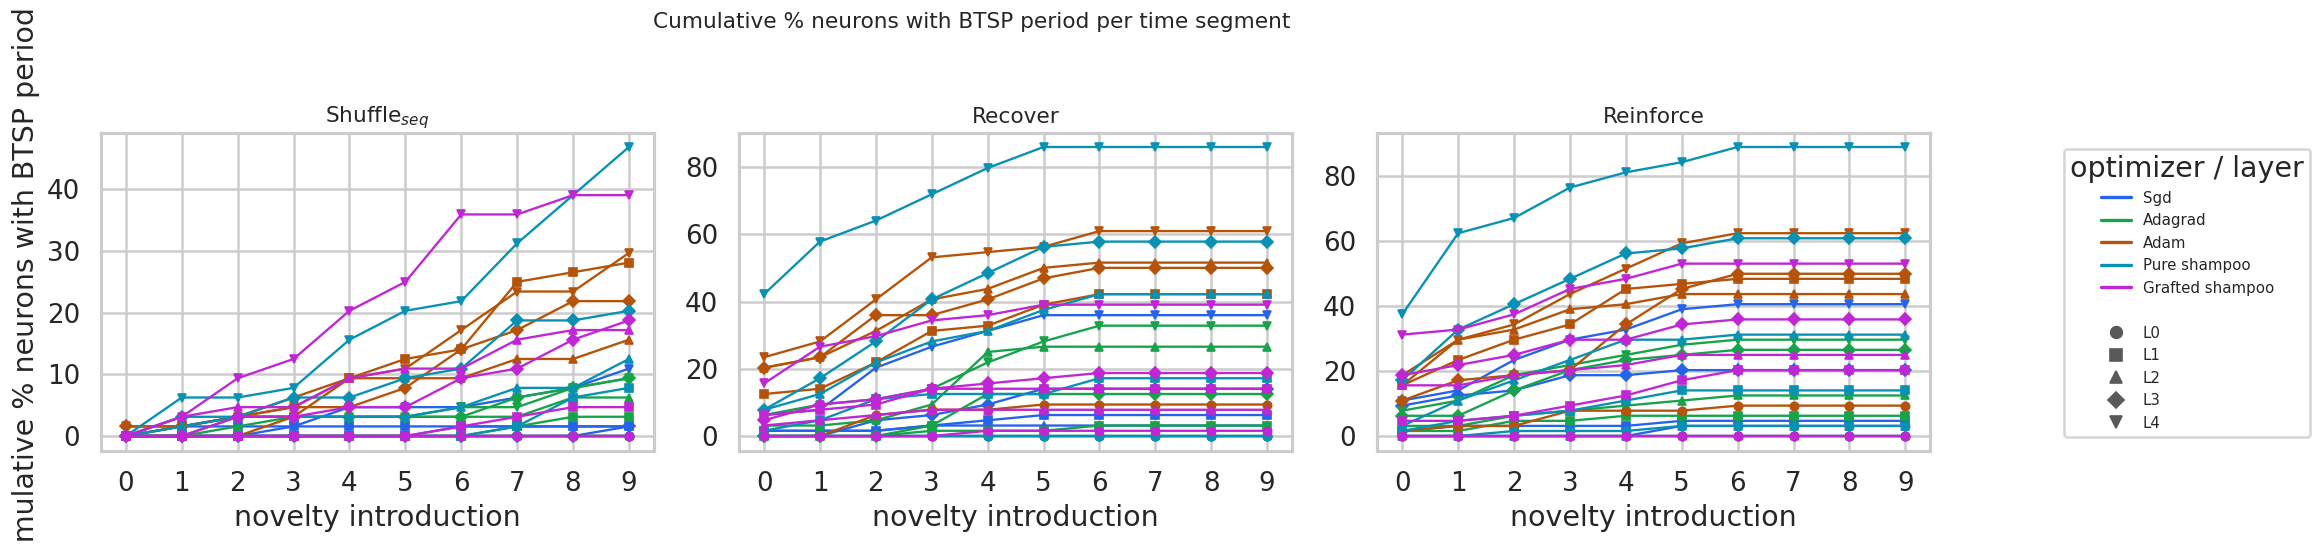

Saved additional_btsp_neuron_pct_cumulative_segments.pdf


In [8]:
for mid, _arch_slug, filename_suffix, title_suffix in iter_model_plot_contexts(DATASET, all_results):
	sub_results = filter_all_results(all_results, mid)
	# Cumulative BTSP neuron % across runs
	# Each x-tick = one experimental run (different digit / digit-pair scenario)
	# Shuffle: 10 runs × 100 post-novelty iters; Recover / Reinforce: 10 runs × 300 iters
	# y = running % of unique neurons seen up to that run (running union, no double-counting)
	df_btsp_seg = build_btsp_neuron_pct_segment_rows(sub_results, rename_experiments, LABELS)
	df_btsp_seg = df_btsp_seg[df_btsp_seg["layer_name"].astype(str) != "head"]
	print(f"btsp cumulative segment rows (model/optimizer/layer/run): {len(df_btsp_seg)}")

	if not df_btsp_seg.empty:
		plot_btsp_neuron_pct_segment_trajectories(
			df_btsp_seg,
			labels=LABELS,
			plot_dir=PLOT_DIR,
			show=True,
			save=True,
			filename_suffix=filename_suffix,
			title_suffix=title_suffix,
		)
		print(
			f"Saved {with_arch_filename('additional_btsp_neuron_pct_cumulative_segments.pdf', filename_suffix)}"
		)
	else:
		print(f"df_btsp_seg empty — skip cumulative segment trajectory plot{title_suffix}")


period metric rows: 2929


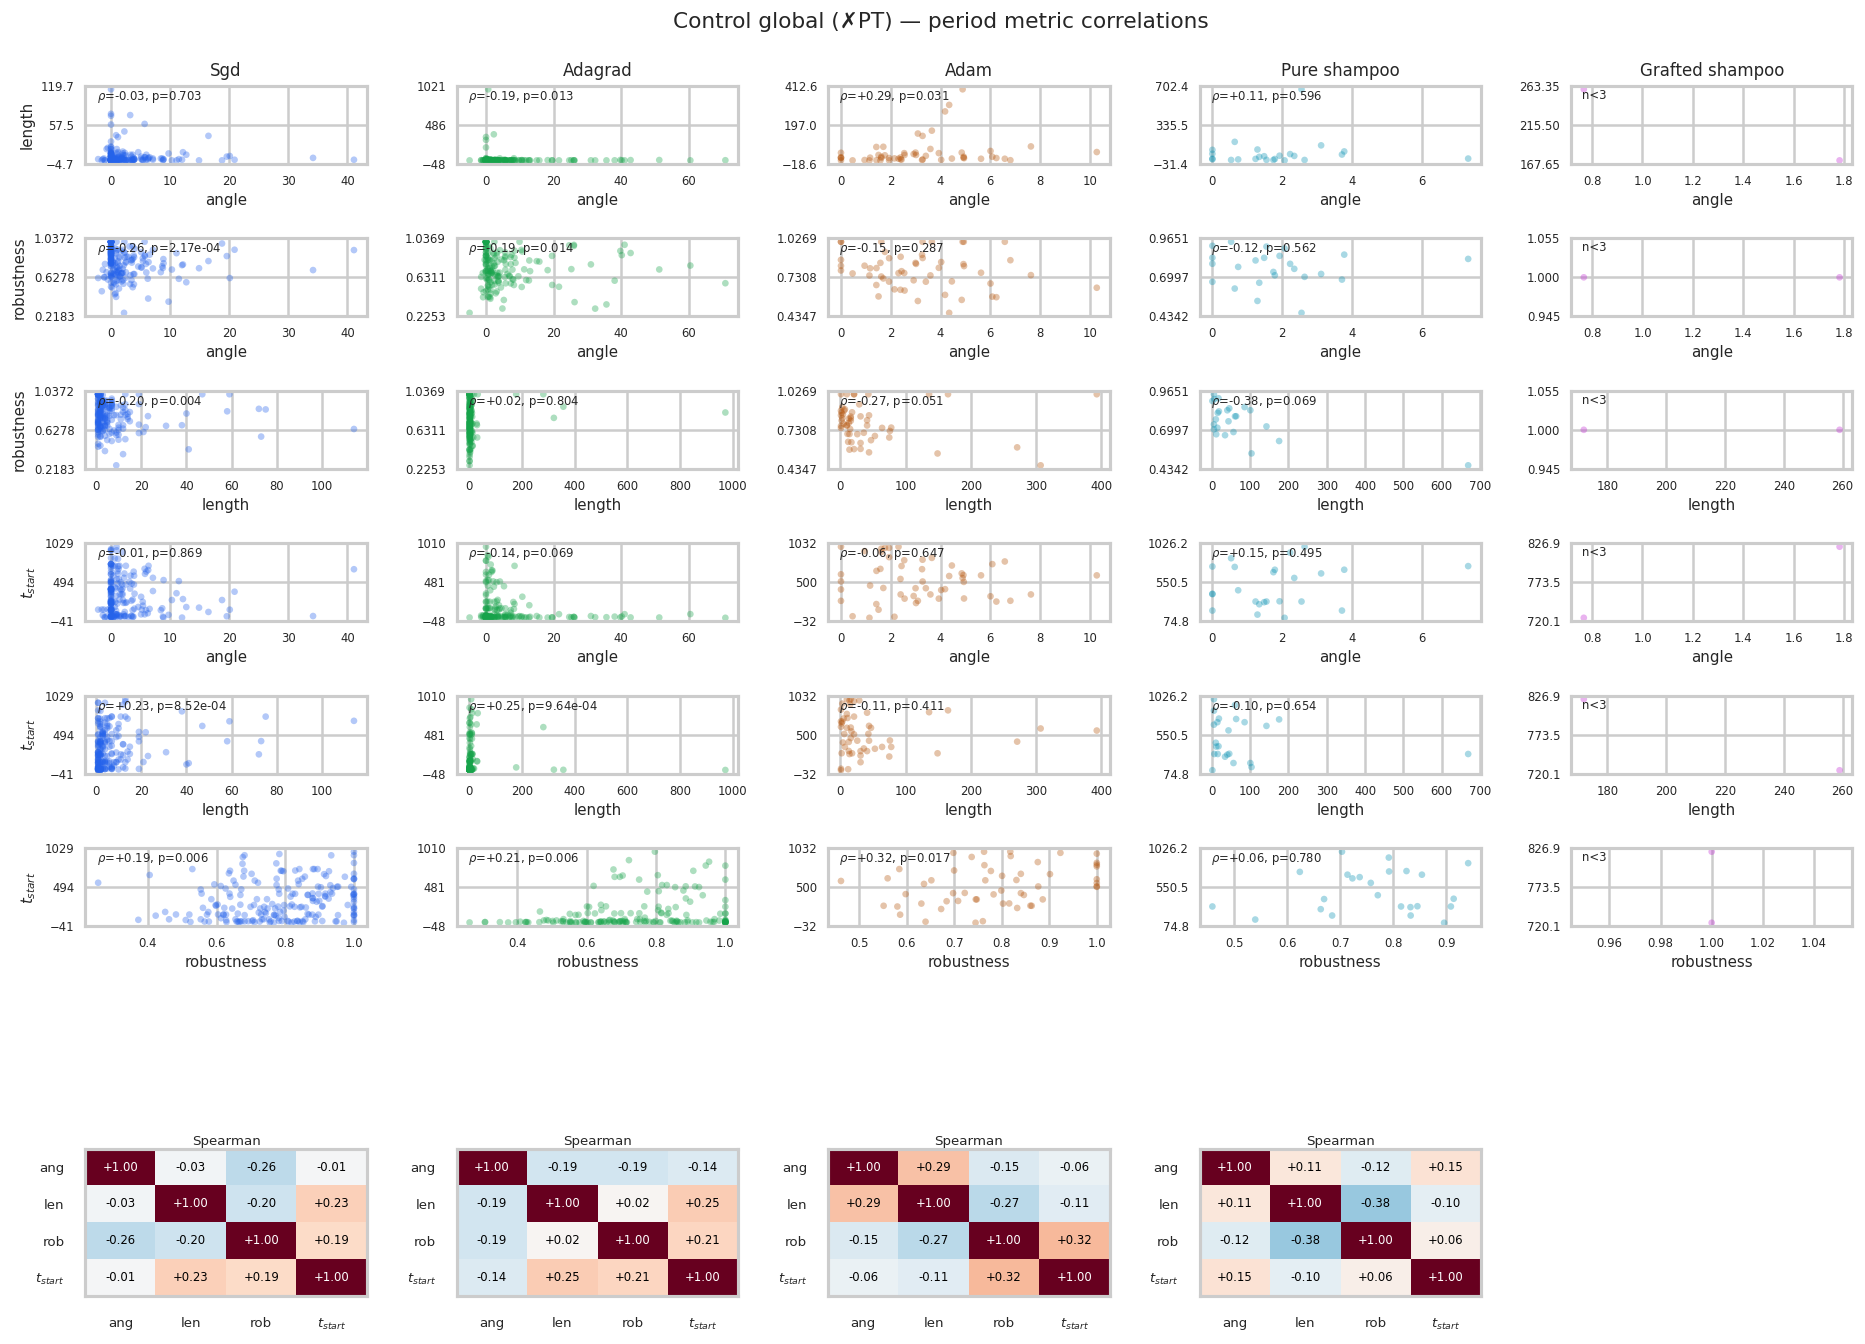

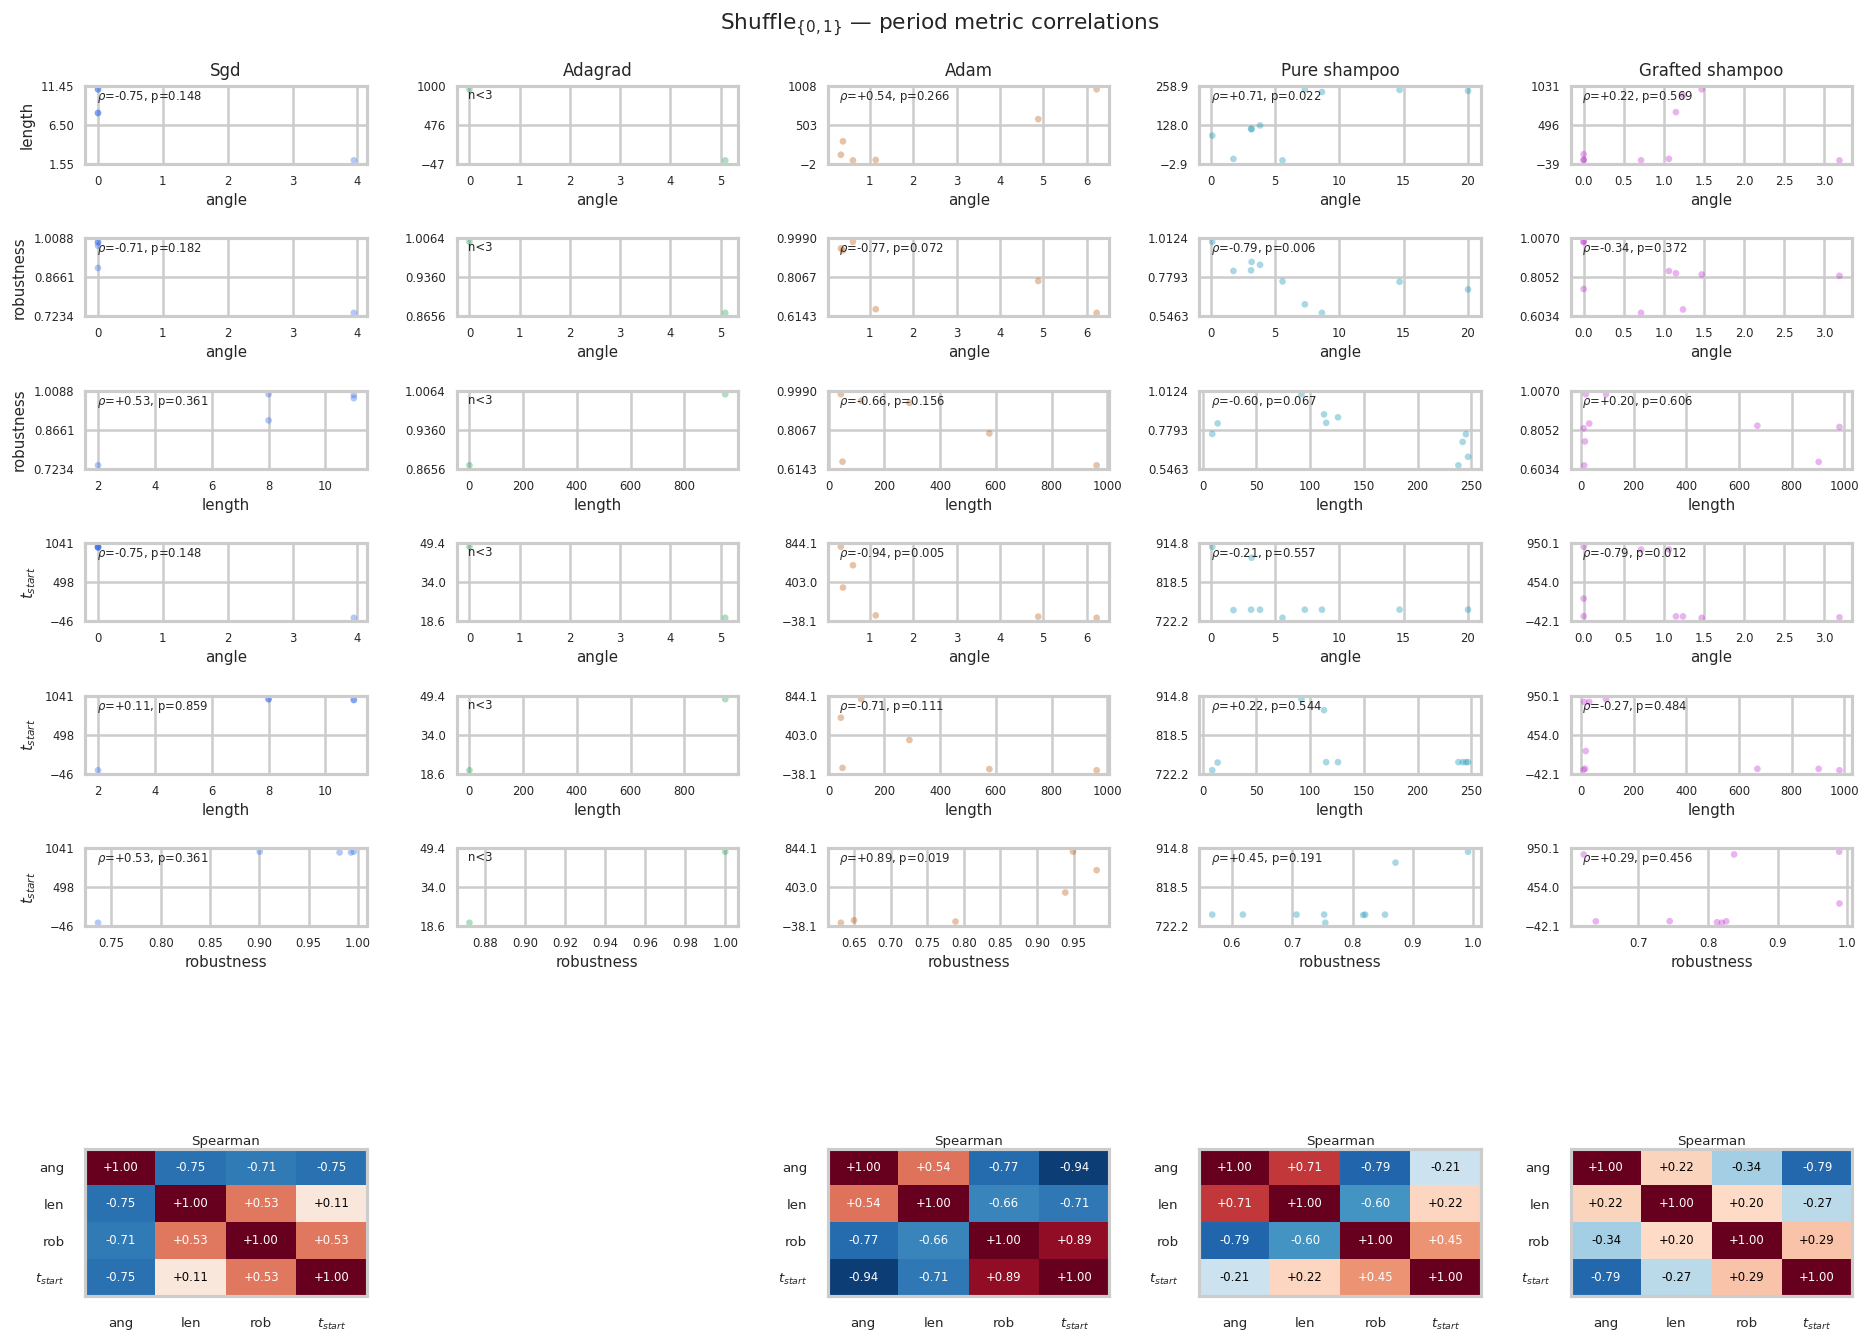

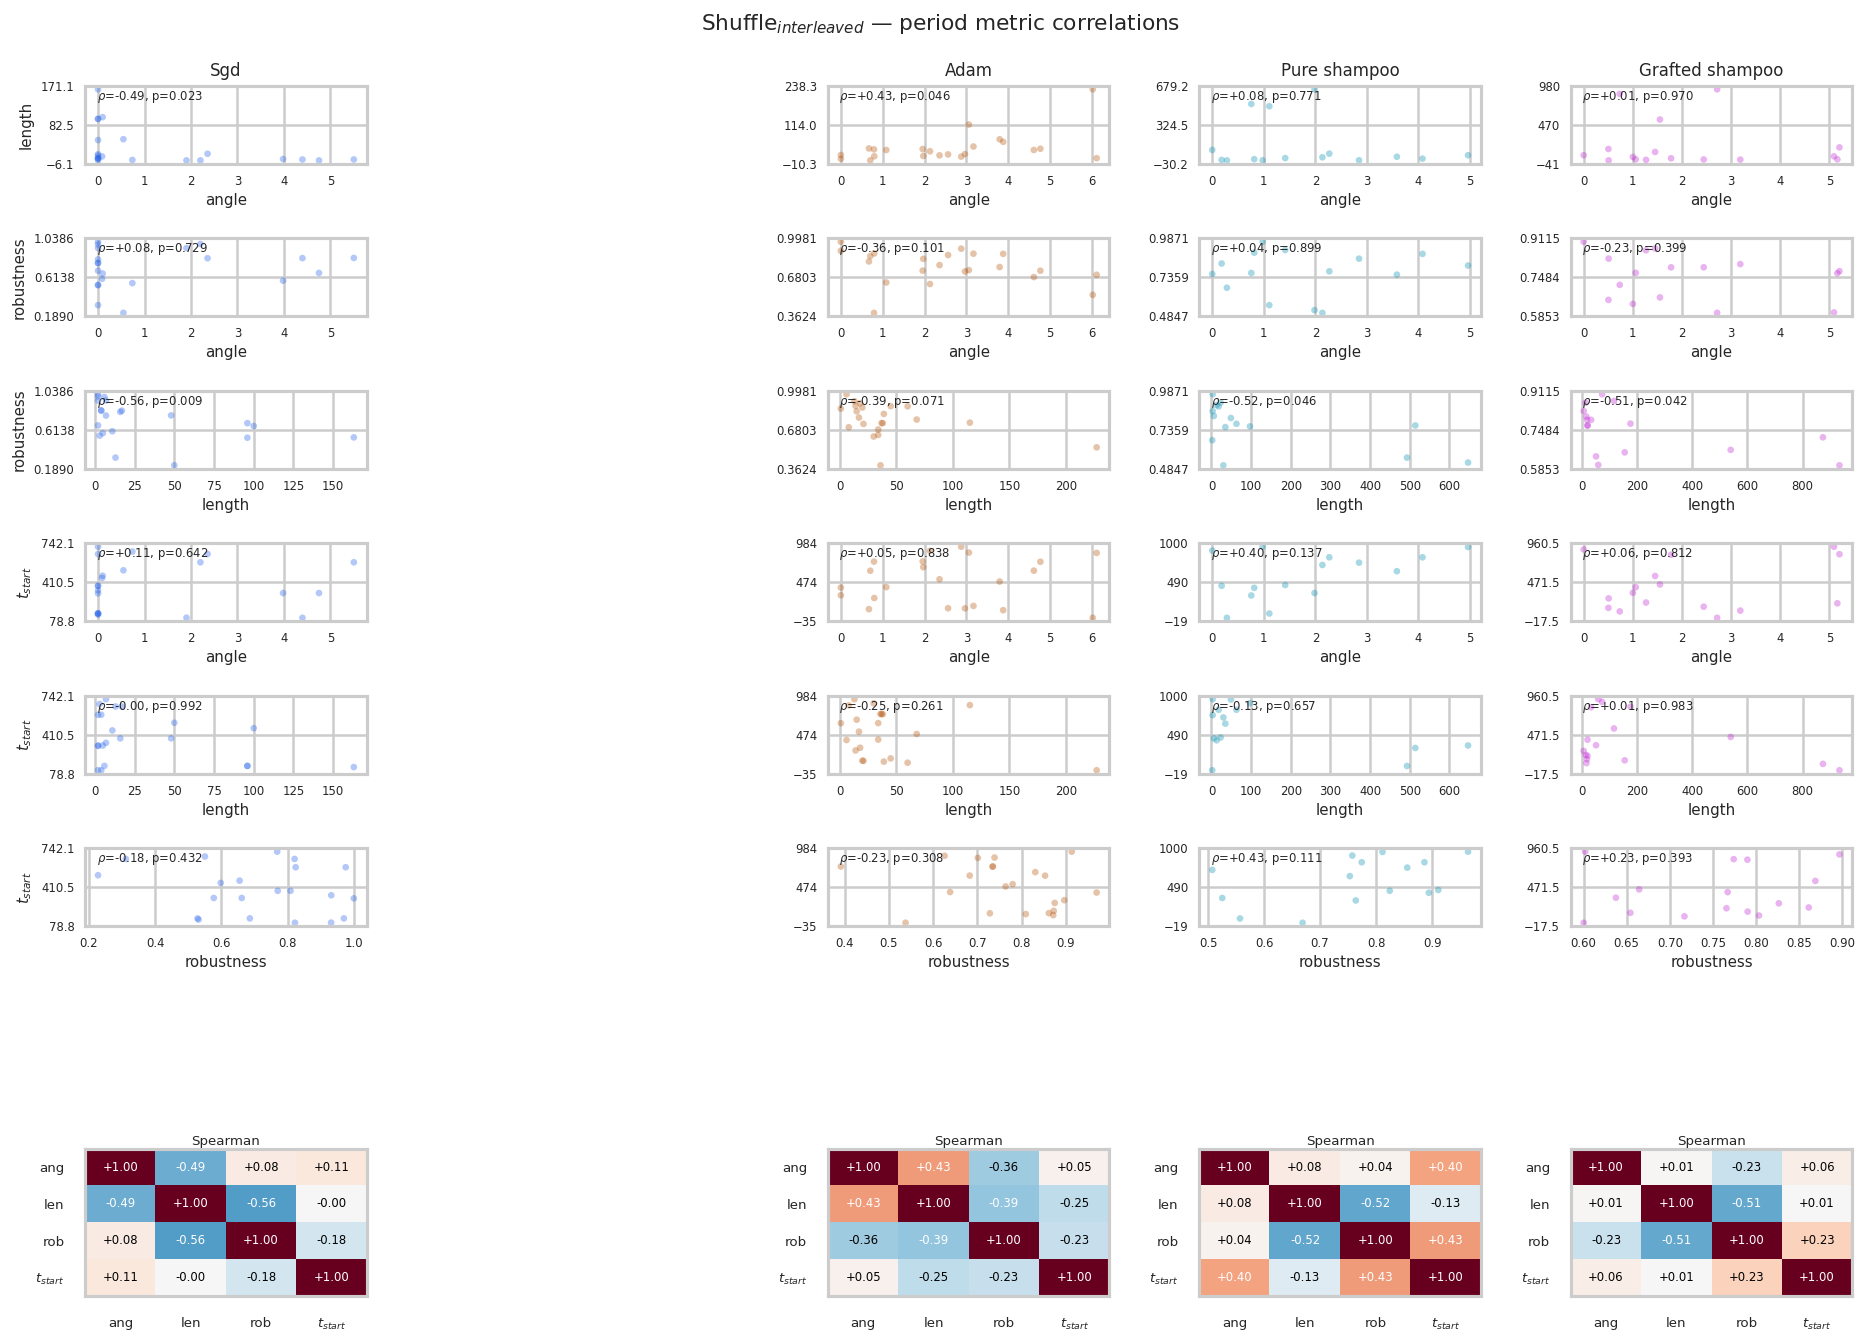

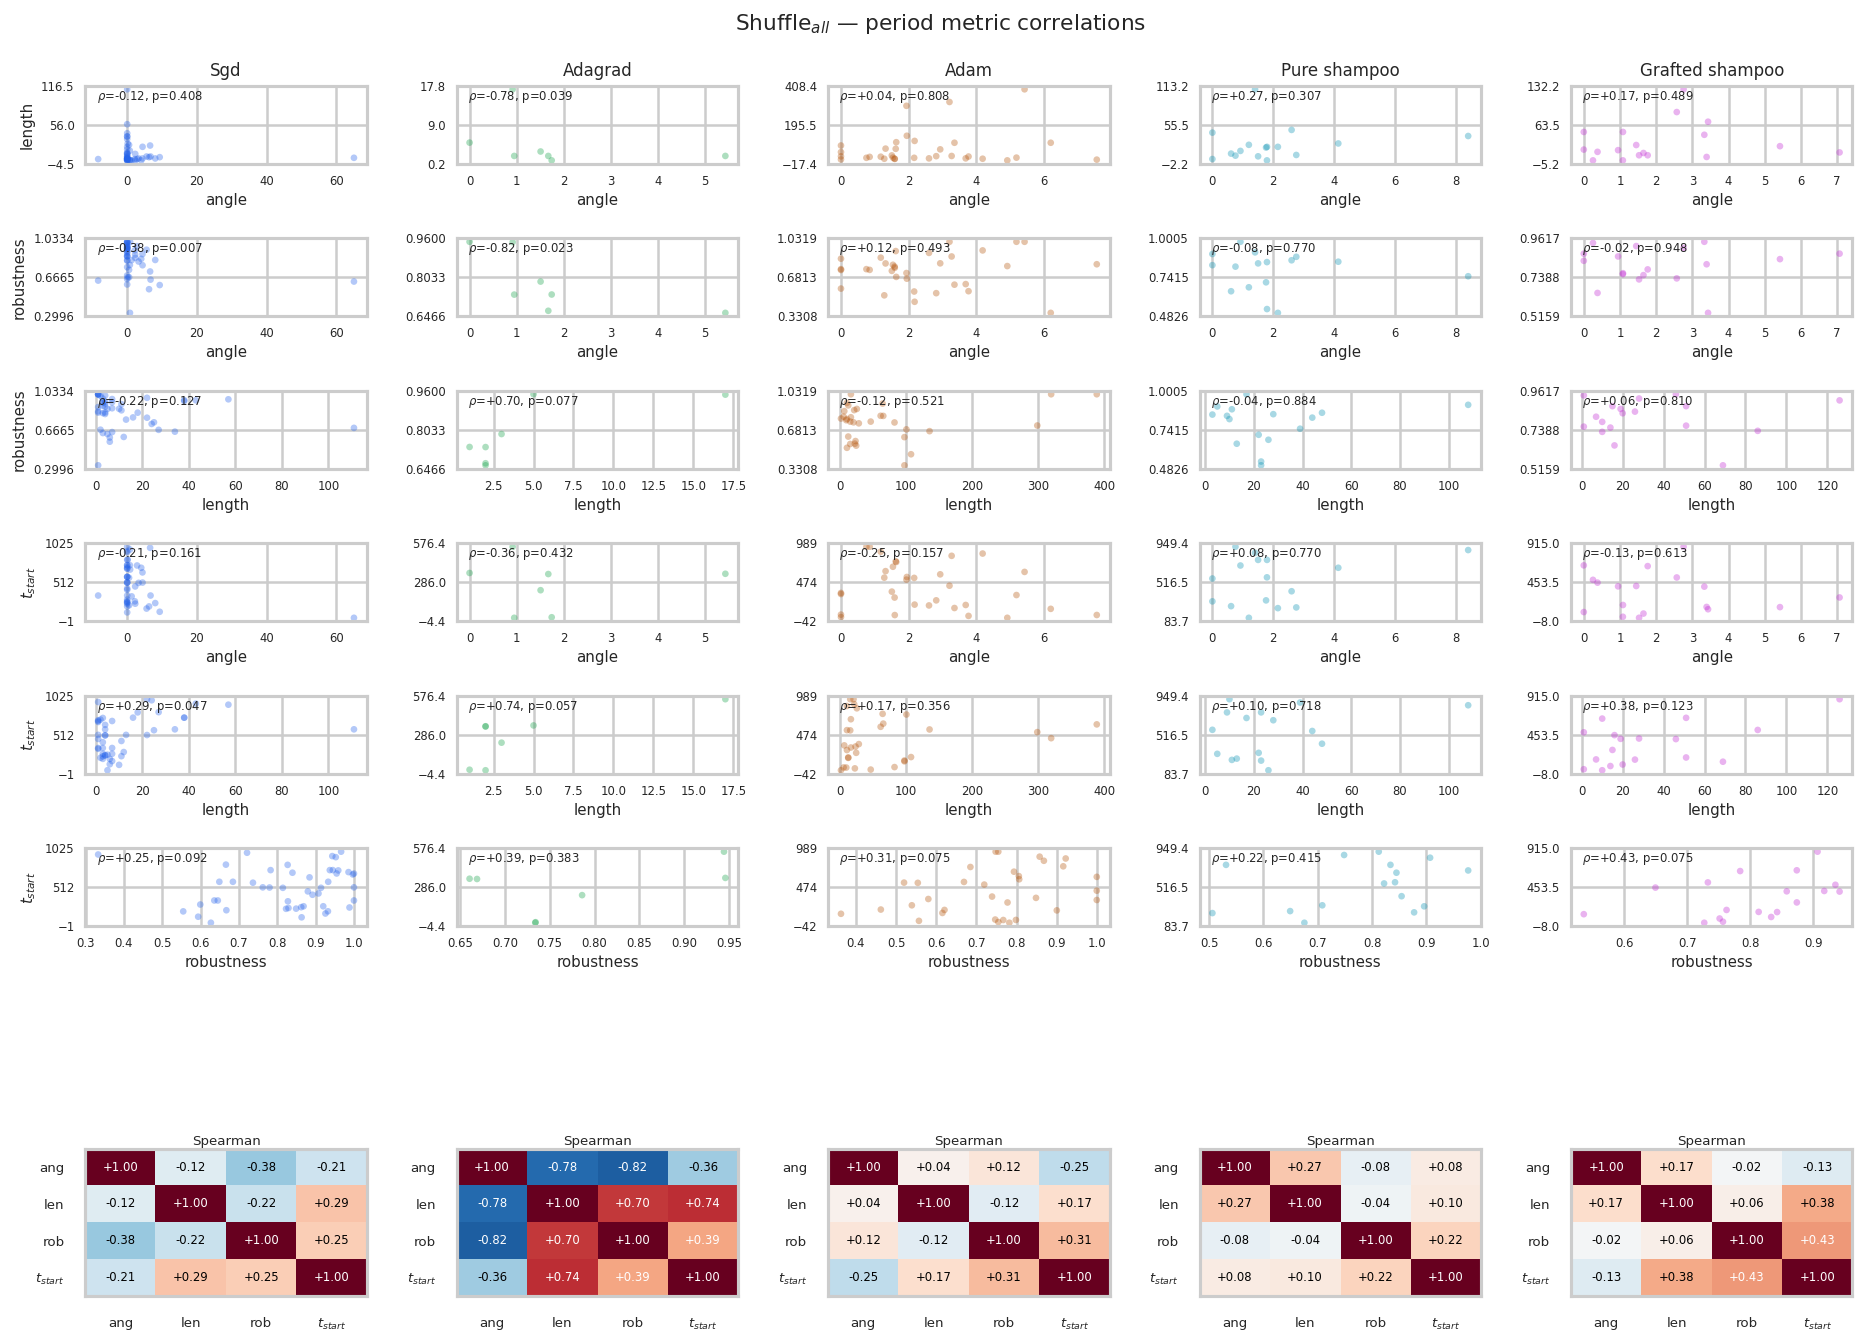

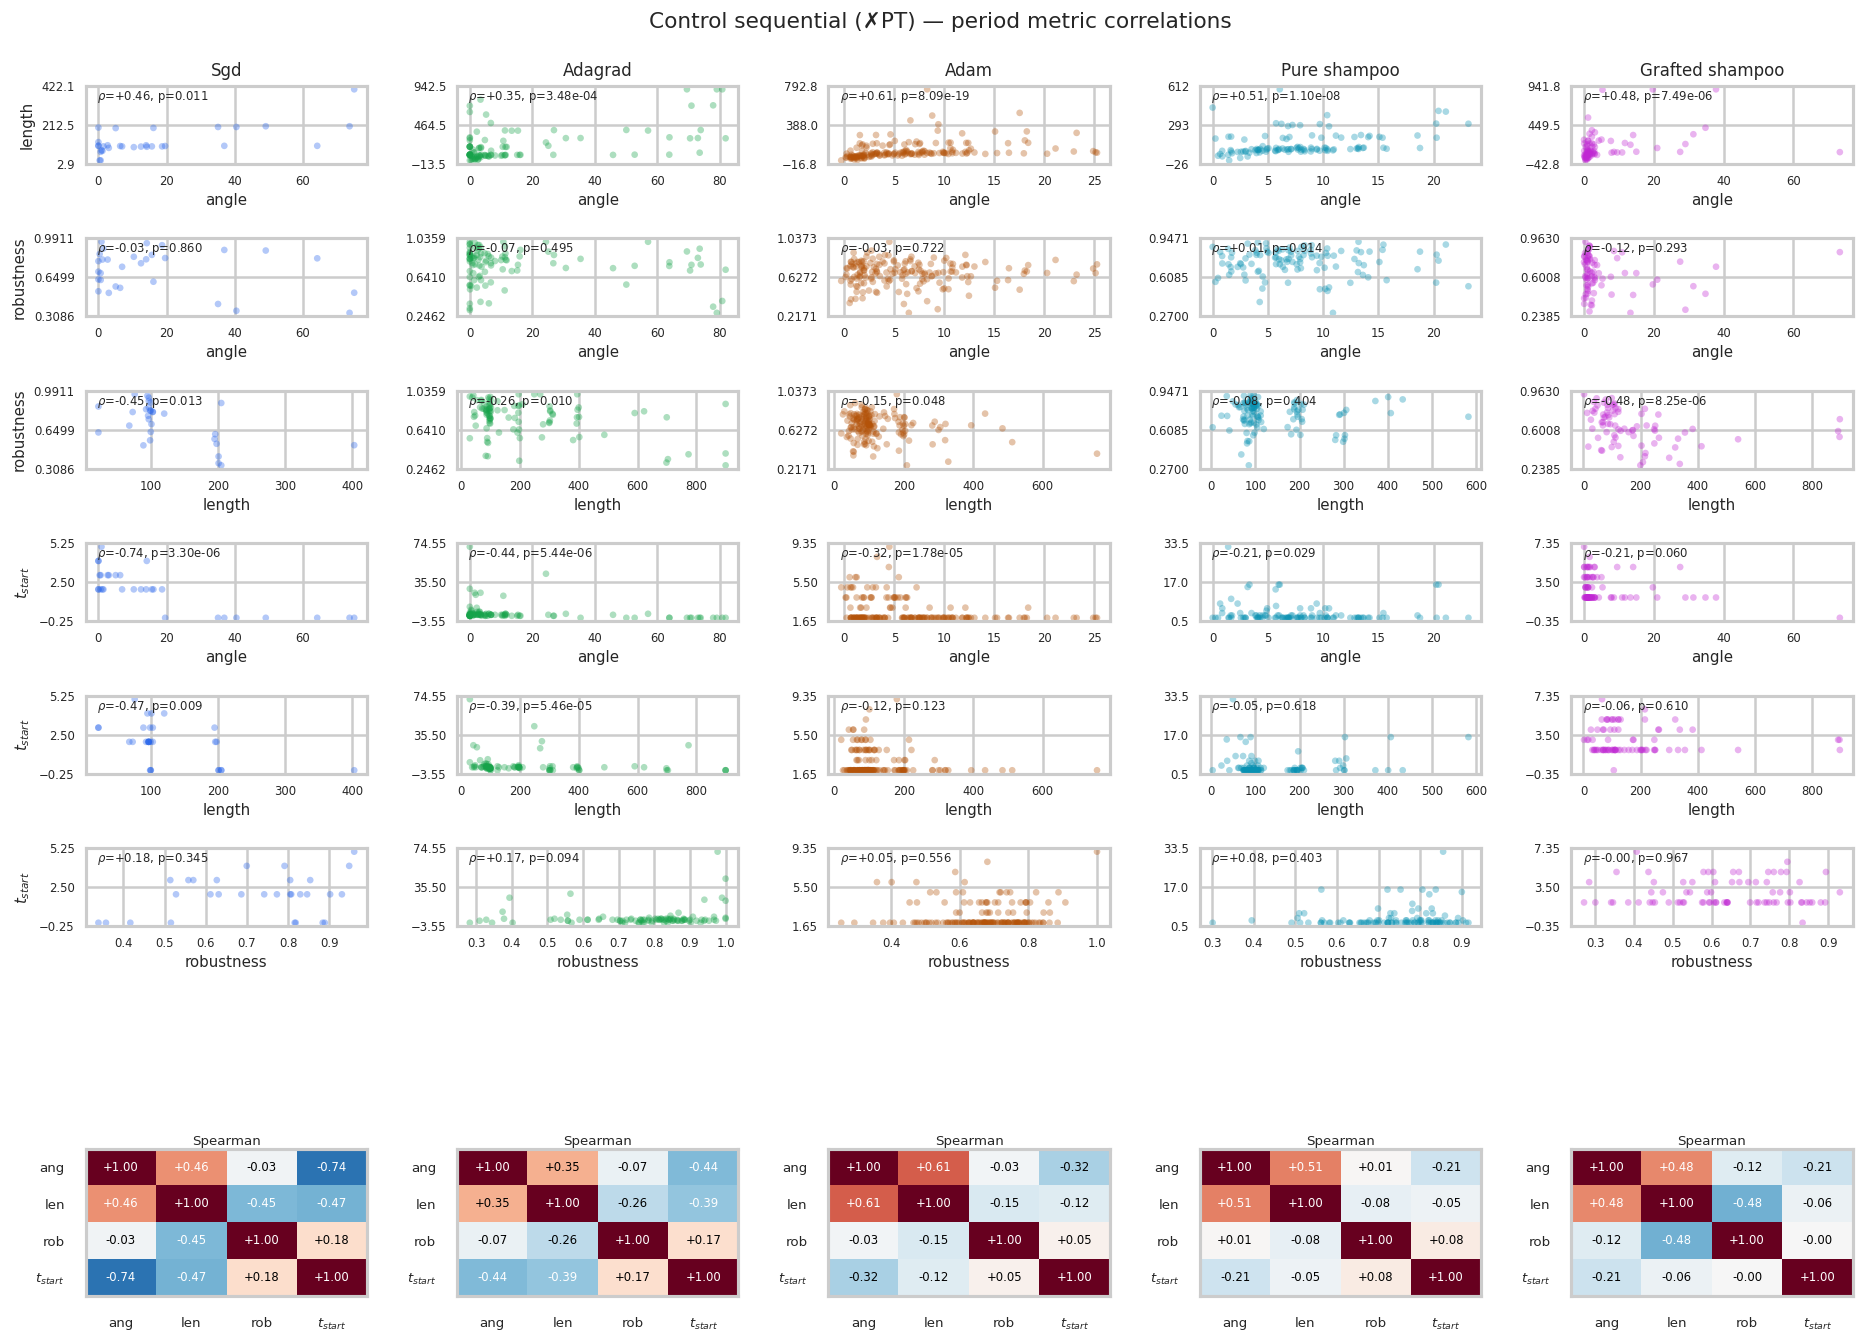

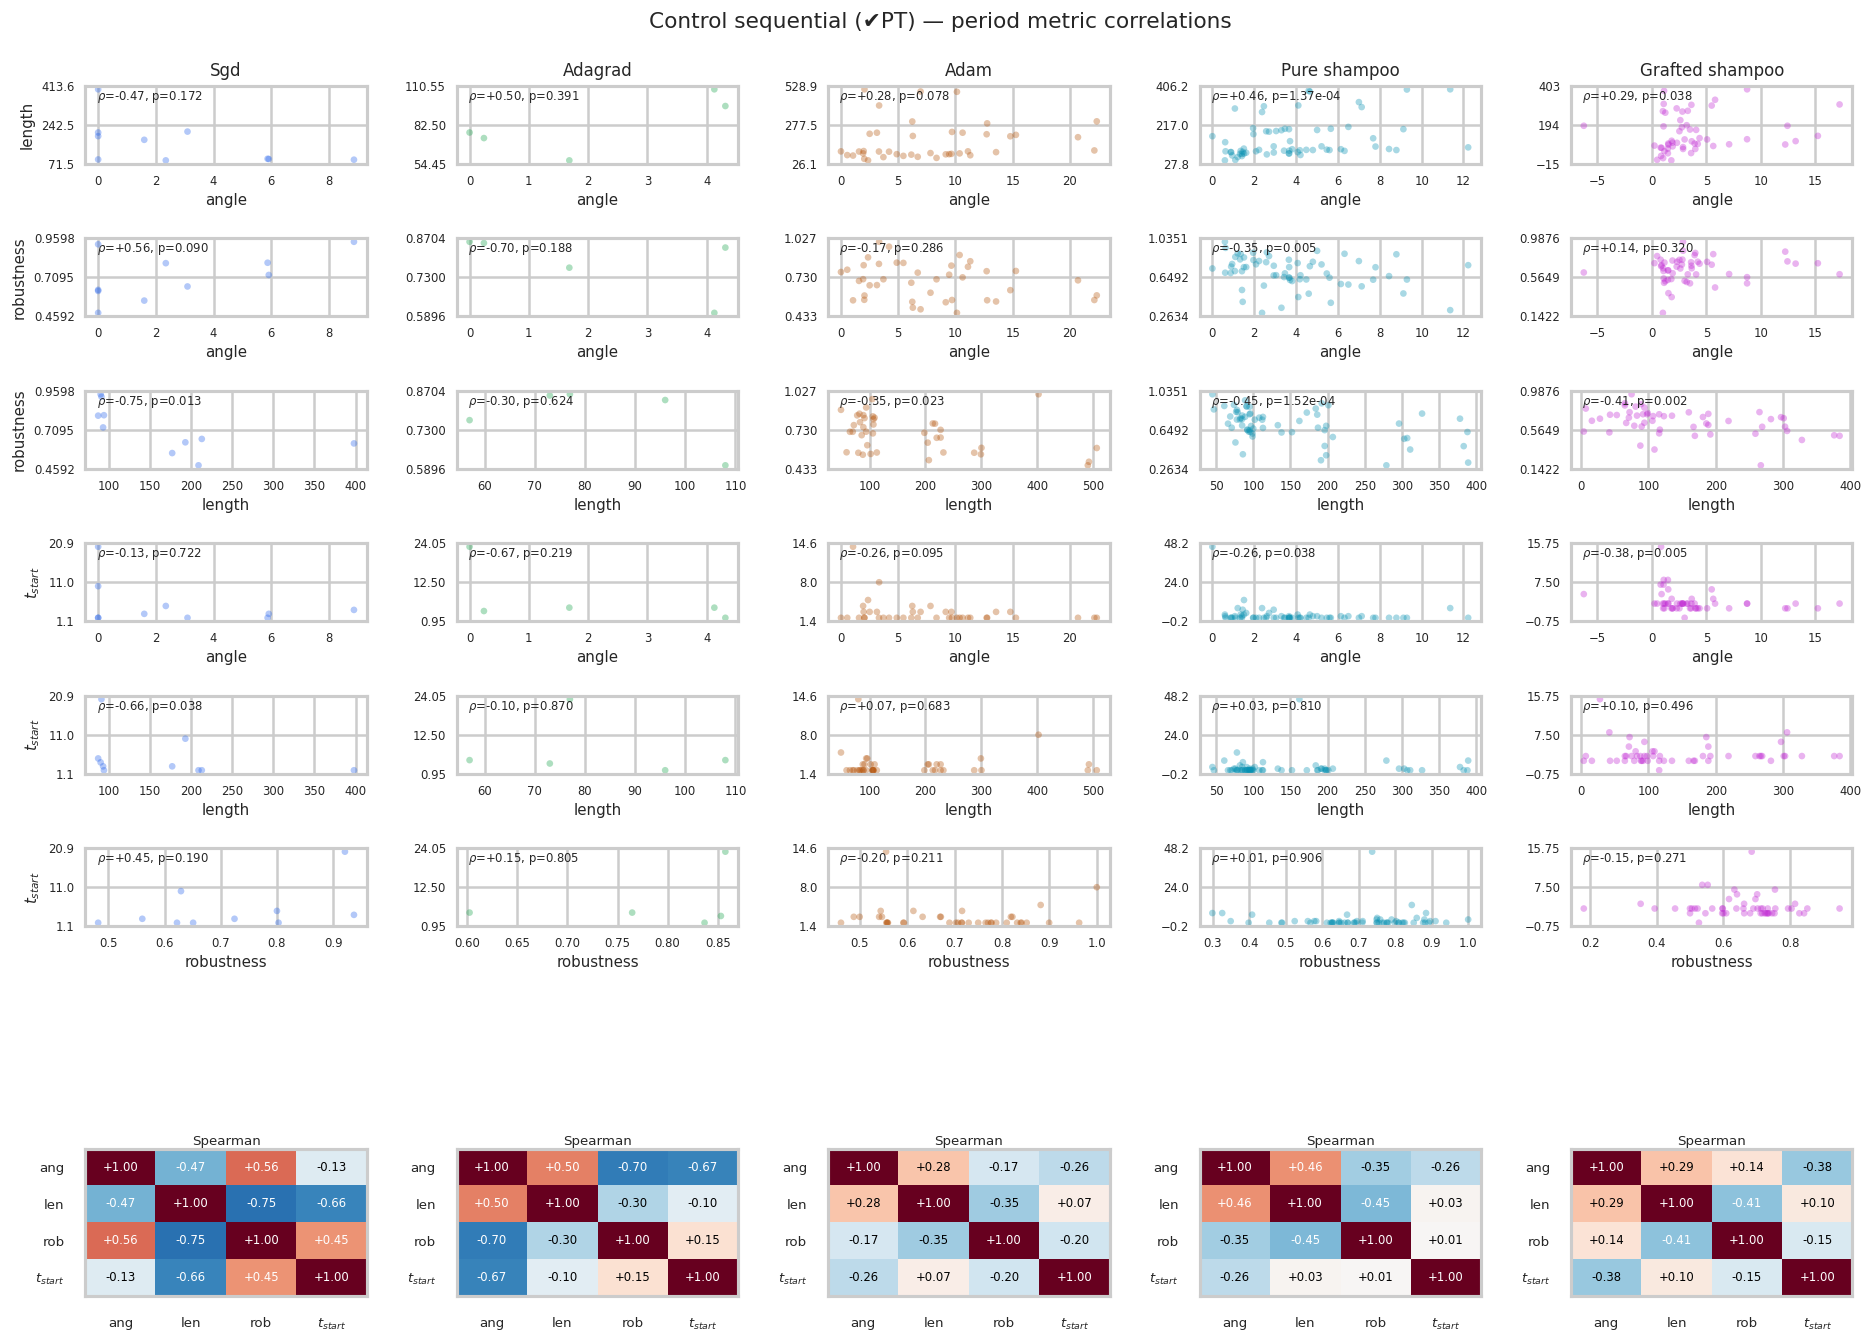

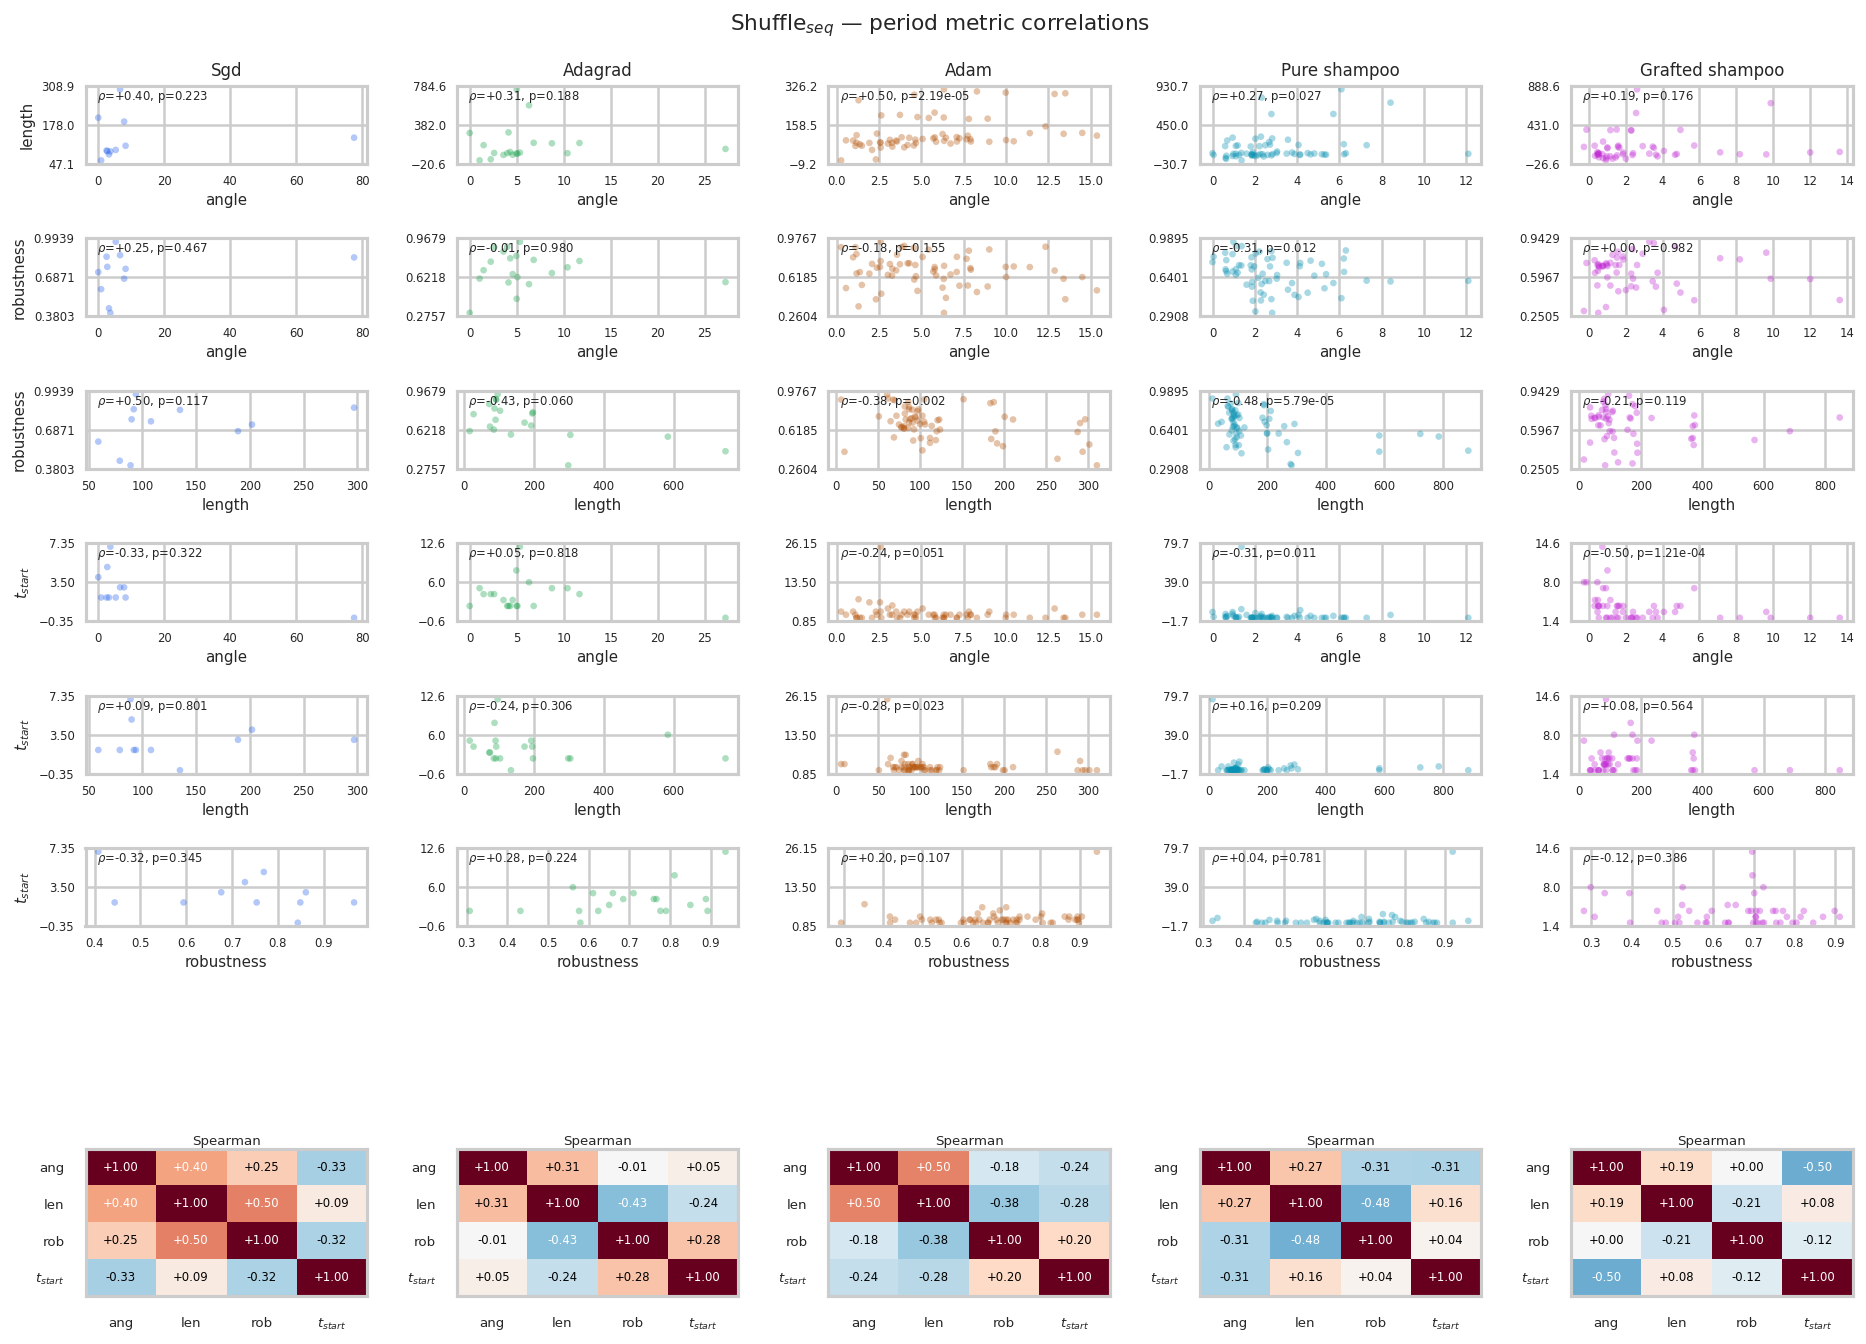

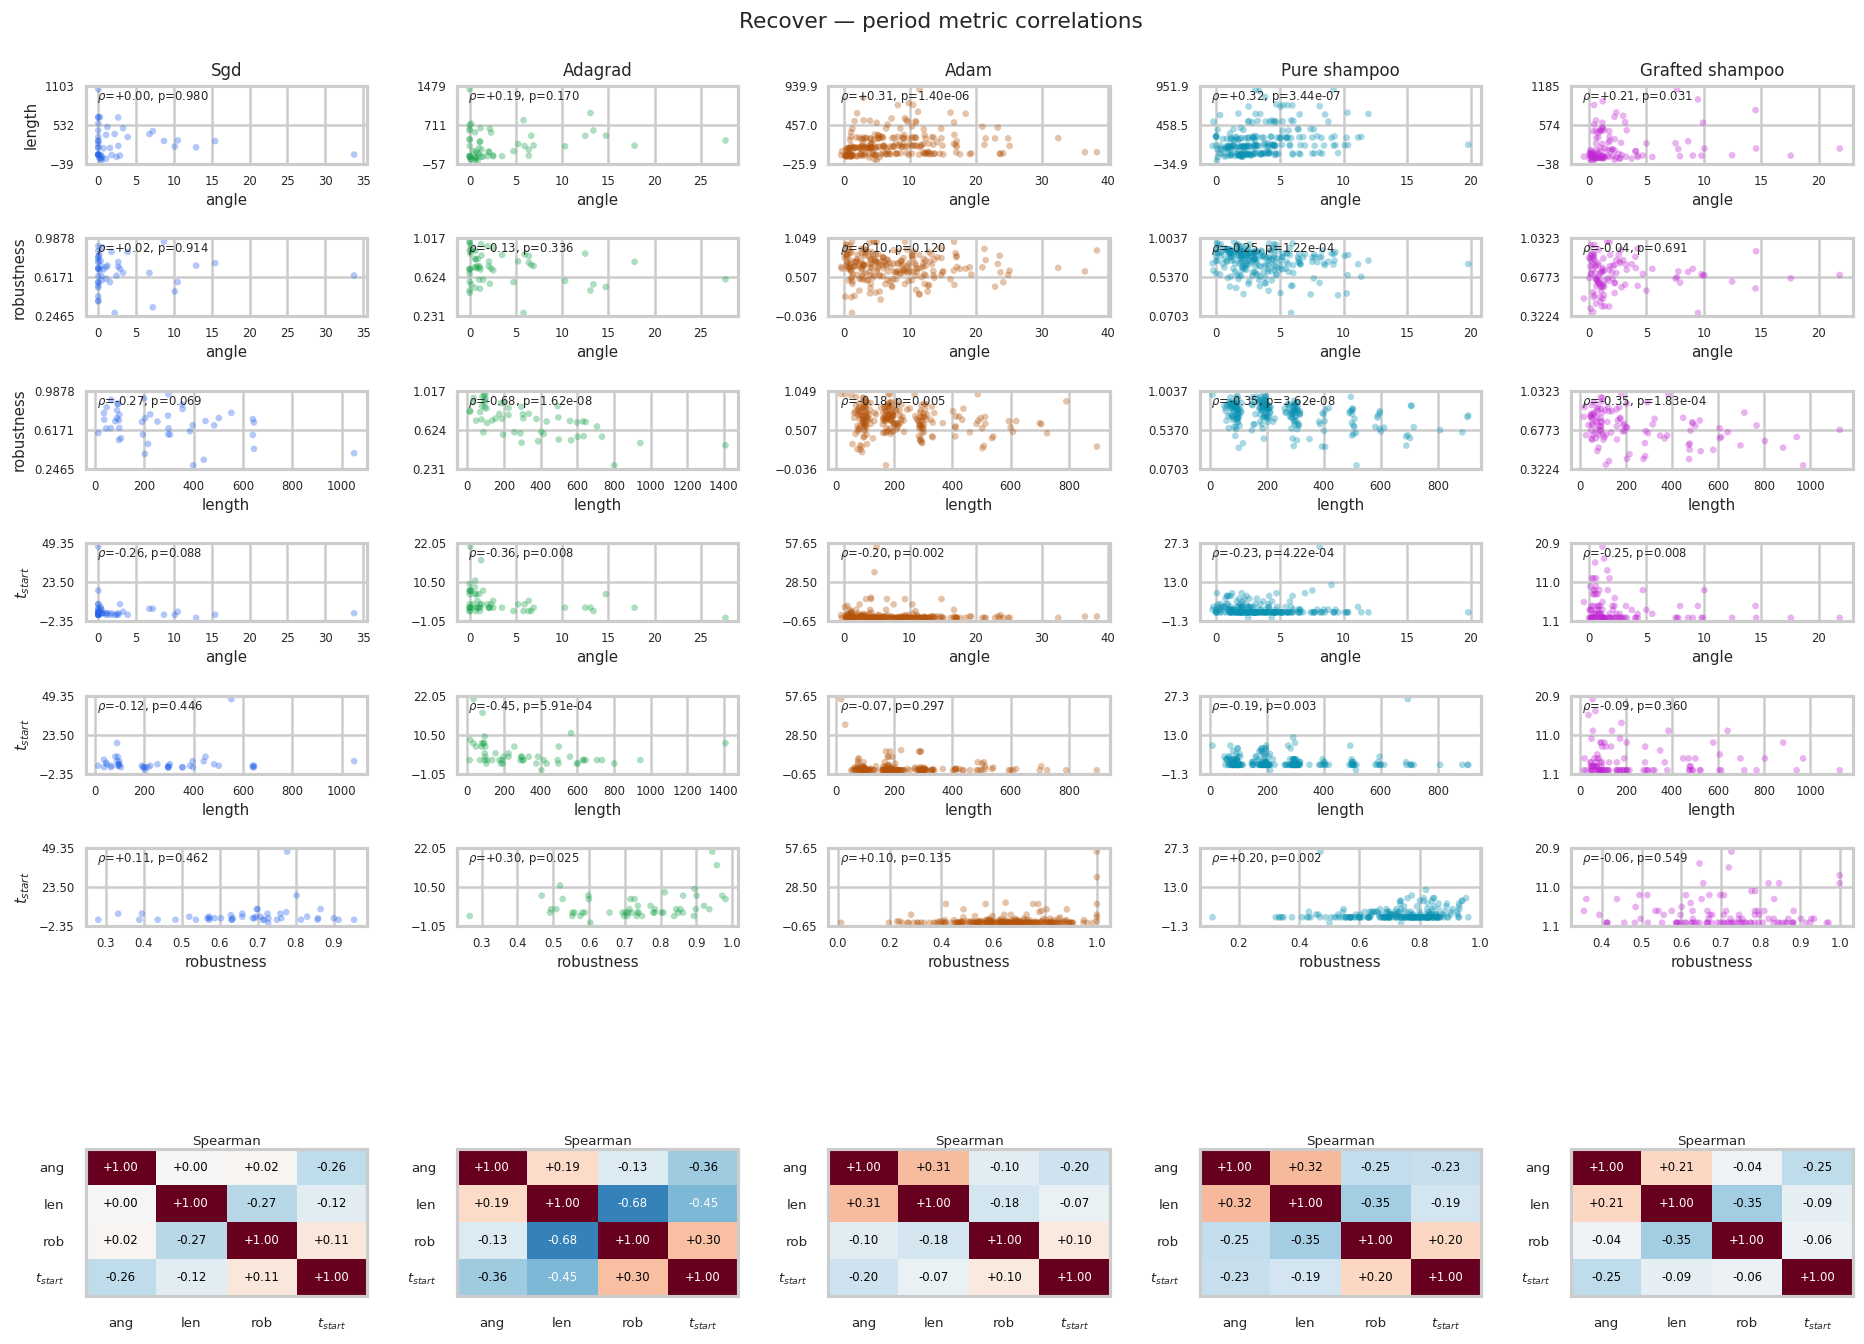

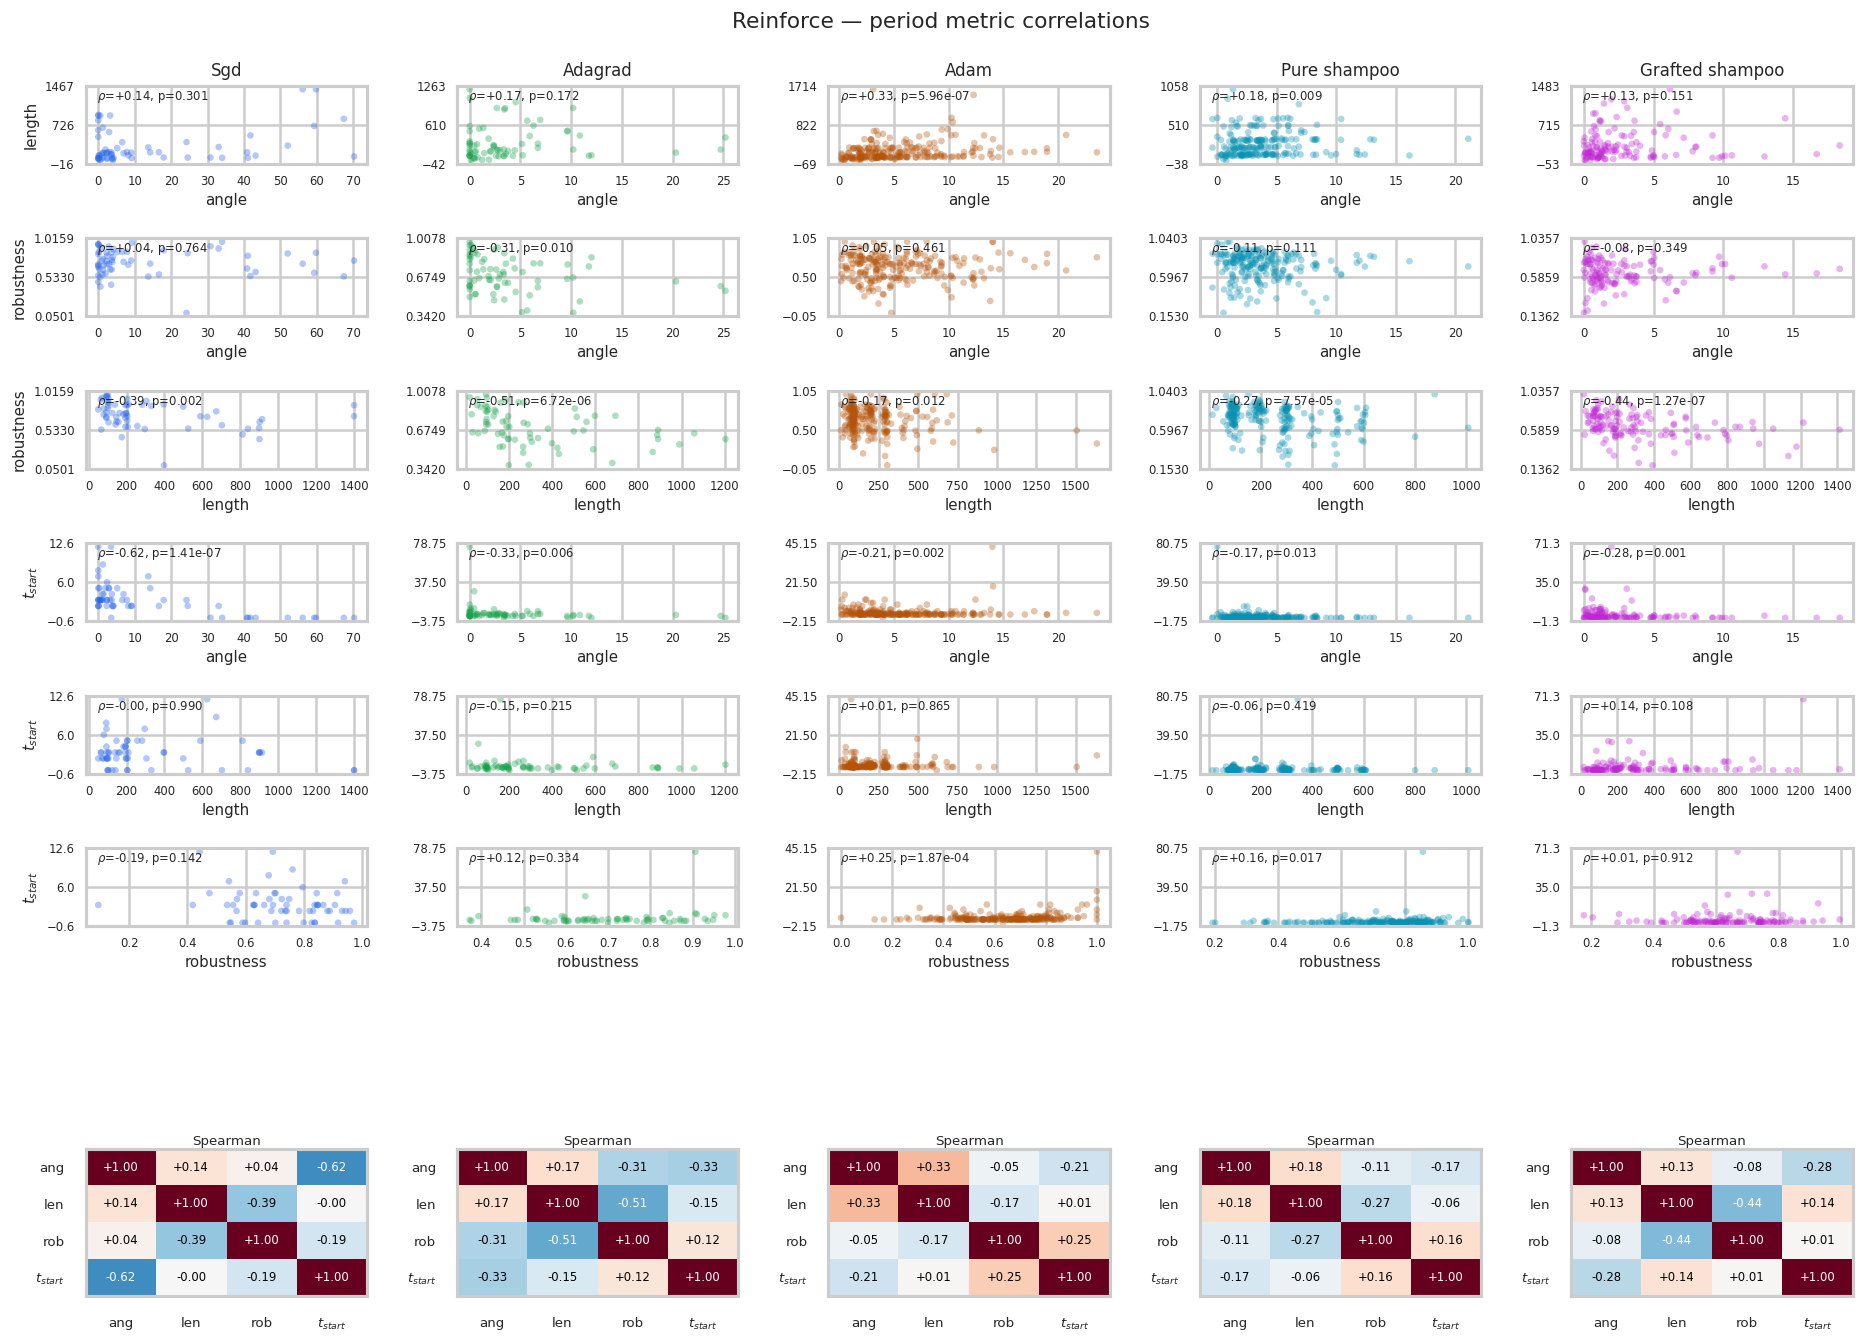

Saved additional_corr_*.pdf per experiment


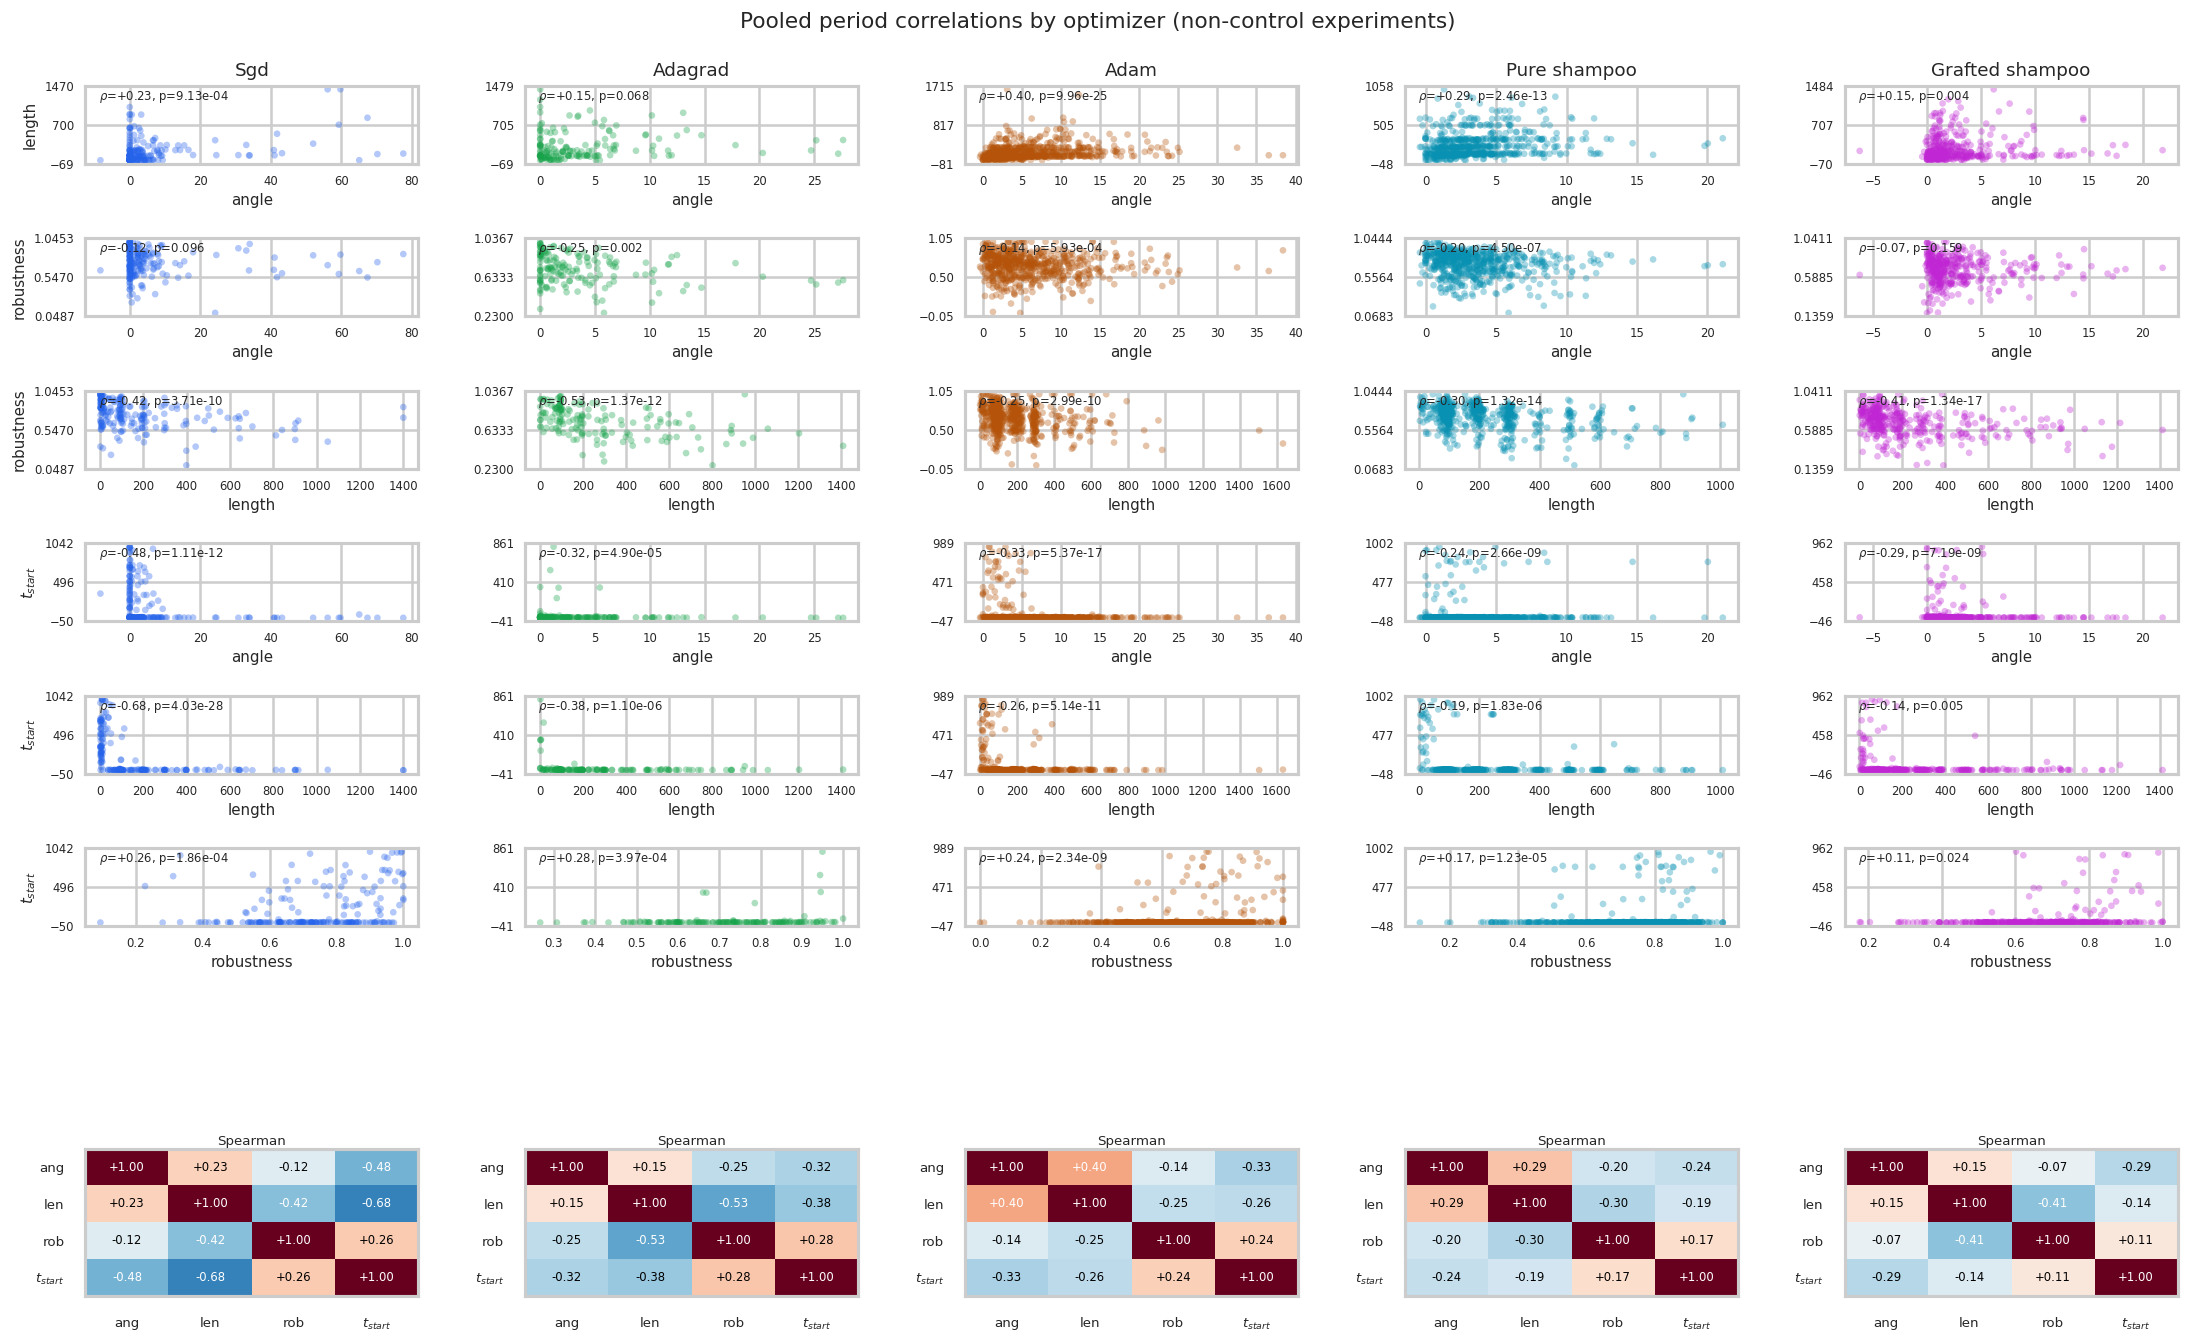

Saved additional_corr_pooled_by_optimizer_no_controls.pdf


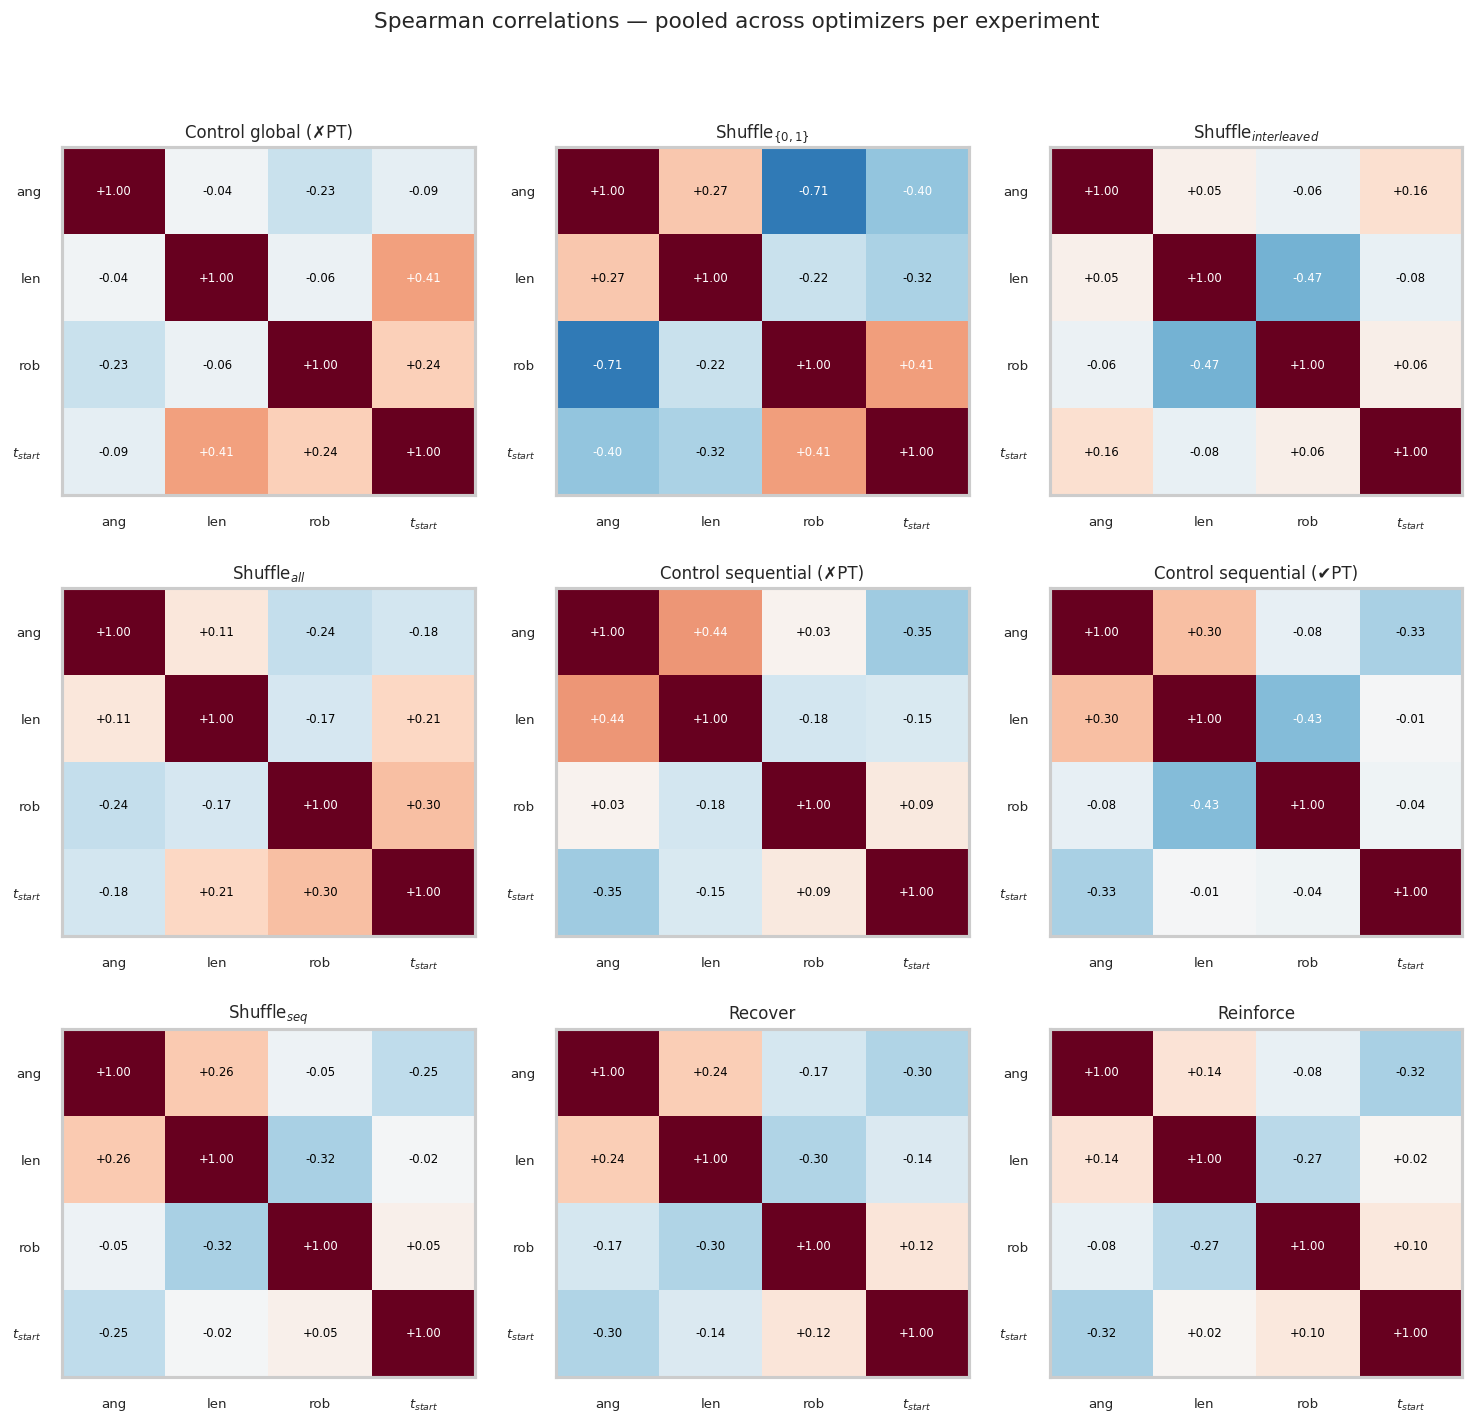

Saved additional_corr_matrix_by_experiment.pdf


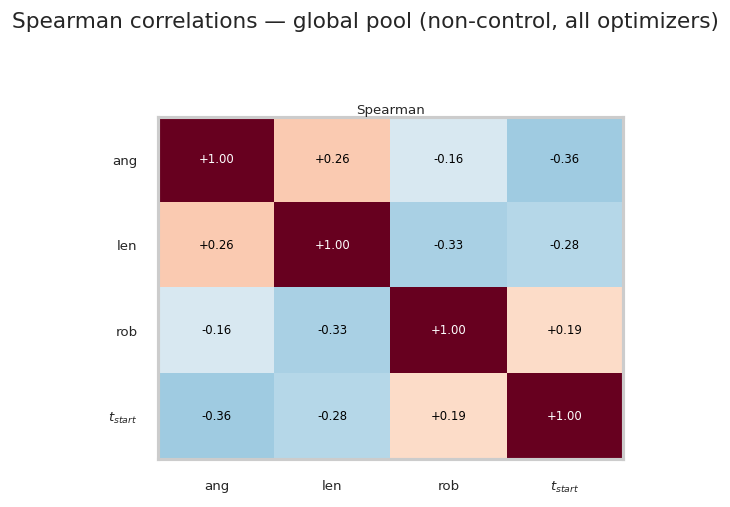

Saved additional_corr_matrix_global_pool.pdf


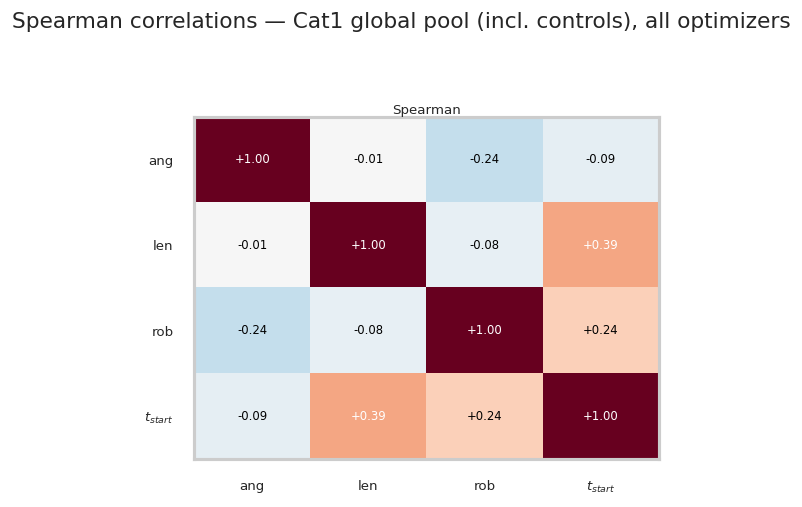

Saved additional_corr_matrix_global_pool_cat1.pdf


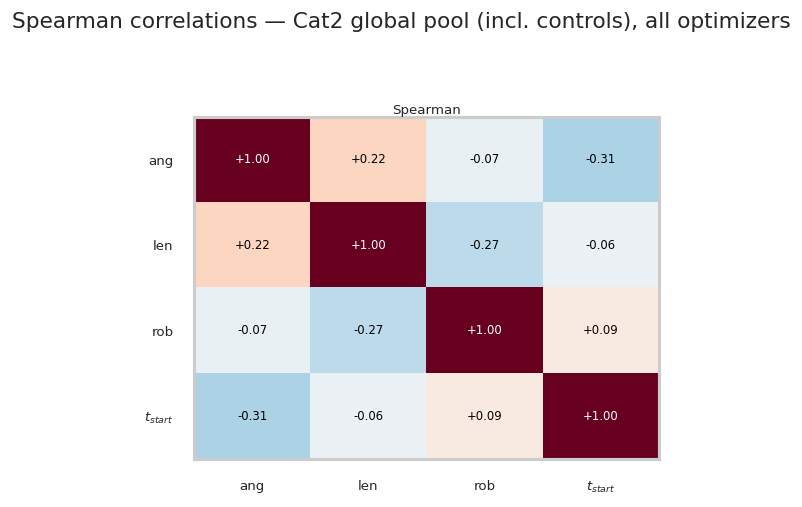

Saved additional_corr_matrix_global_pool_cat2.pdf


In [9]:
for mid, _arch_slug, filename_suffix, title_suffix in iter_model_plot_contexts(DATASET, all_results):
	sub_results = filter_all_results(all_results, mid)
	# Correlations: angle, length, robustness, t_start (offset from novelty; cat1 = trial_start+PMA, cat2 = PMA)
	df_period_metrics = build_period_metrics_df(sub_results, rename_experiments)
	print(f"period metric rows: {len(df_period_metrics)}")

	if not df_period_metrics.empty:
		df_period_copy = df_period_metrics.copy()
		df_period_copy["t_start_inv"] = - df_period_copy["t_start"]
		_corr_matrix_kw = dict(
			filename_suffix=filename_suffix,
			plot_dir=PLOT_DIR,
			sort_experiment_names=_sort_experiment_display_names,
			corr_mat_cols=_CORR_MAT_COLS,
			corr_mat_labels=_CORR_MAT_LABELS,
			show=True,
		)
		_corr_scatter_kw = dict(_corr_matrix_kw, corr_pairs=_CORR_PAIRS)
		plot_correlations_per_experiment(df_period_copy, **_corr_scatter_kw)
		print(f"Saved additional_corr_*{filename_suffix}.pdf per experiment")
		plot_correlations_pooled_by_optimizer(
			df_period_copy,
			labels=LABELS,
			**_corr_scatter_kw,
		)
		print(
			f"Saved {with_arch_filename('additional_corr_pooled_by_optimizer_no_controls.pdf', filename_suffix)}"
		)
		plot_correlation_matrices_pooled_by_experiment(df_period_copy, **_corr_matrix_kw)
		print(
			f"Saved {with_arch_filename('additional_corr_matrix_by_experiment.pdf', filename_suffix)}"
		)
		plot_correlation_matrix_global_pool(
			df_period_copy,
			plot_dir=PLOT_DIR,
			filename_suffix=filename_suffix,
			labels=LABELS,
			corr_mat_cols=_CORR_MAT_COLS,
			corr_mat_labels=_CORR_MAT_LABELS,
			show=True,
		)
		print(
			f"Saved {with_arch_filename('additional_corr_matrix_global_pool.pdf', filename_suffix)}"
		)
		plot_correlation_matrix_global_pool(
			df_period_copy,
			plot_dir=PLOT_DIR,
			filename_suffix=filename_suffix,
			labels=LABELS,
			corr_mat_cols=_CORR_MAT_COLS,
			corr_mat_labels=_CORR_MAT_LABELS,
			show=True,
			category="cat1",
			exclude_controls=False,
		)
		print(
			f"Saved {with_arch_filename('additional_corr_matrix_global_pool_cat1.pdf', filename_suffix)}"
		)
		plot_correlation_matrix_global_pool(
			df_period_copy,
			plot_dir=PLOT_DIR,
			filename_suffix=filename_suffix,
			labels=LABELS,
			corr_mat_cols=_CORR_MAT_COLS,
			corr_mat_labels=_CORR_MAT_LABELS,
			show=True,
			category="cat2",
			exclude_controls=False,
		)
		print(
			f"Saved {with_arch_filename('additional_corr_matrix_global_pool_cat2.pdf', filename_suffix)}"
		)
	else:
		print(f"df_period_metrics empty — skip correlation plots{title_suffix}")
